In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import cm
import cartopy.crs as ccrs
from keras.layers import Dense, SimpleRNN, LSTM, GRU, Reshape 
from keras import initializers
import matplotlib.pyplot as plt 
from keras.models import Sequential 
from keras.optimizers import RMSprop
import tensorflow.keras as keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from keras import layers
from keras import models
from tensorflow.keras import models
from datetime import datetime
import os
import scipy
import matplotlib.dates as dates
import xskillscore as xs
#from functions_verification import *
#from functions_rf import *

2026-04-03 14:07:43.326965: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
input_folder_noemi="/Volumes/SPARK/noemi/noemi_rec/Imfeld_2022_allfiles/"
input_folder_martin="/Volumes/SPARK/RNN_savestates/1807/tabs_highres/forward_peter/"
plot_folder="/Users/mwegmann/Dropbox/SPARK_WINTER/1807/plots/"

In [3]:
focus_year="1807"

In [4]:
dropout="001"

# read in

## Noemi

In [5]:
noemi=xr.open_dataset(input_folder_noemi+"CH_temp_EnKF_"+focus_year+"-01-01-"+focus_year+"-12-31.nc")

In [6]:
noemi=noemi.temp.isel(time=np.arange(1,365)) # remove 1st of January for conistency with ML data sets (pressure gradient)

In [7]:
noemi

<xarray.DataArray 'temp' (time: 364, N: 240, E: 370)> Size: 129MB
[32323200 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 3kB 1807-01-02 1807-01-03 ... 1807-12-31
  * E        (E) float64 3kB 2.474e+06 2.476e+06 ... 2.842e+06 2.844e+06
  * N        (N) float64 2kB 1.064e+06 1.066e+06 ... 1.302e+06 1.304e+06
Attributes:
    long_name:     daily mean temperature
    units:         degC
    grid_mapping:  swiss_lv95_coordinates
    grid_name:     ch01r.swiss.lv95
    prod_date:     2023-02-21
    version:       v1.1

## martins reconstructions

In [8]:
martin_mse12 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_norr0_"+dropout+"_mse_m*.nc",combine="nested",concat_dim="member")
martin_mse13 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_withrr0_"+dropout+"_mse_m*.nc",combine="nested",concat_dim="member")
martin_mae12 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_norr0_"+dropout+"_mae_m*.nc",combine="nested",concat_dim="member")
martin_mae13 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_withrr0_"+dropout+"_mae_m*.nc",combine="nested",concat_dim="member")
martin_mae212 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_norr0_"+dropout+"_mae2_m*.nc",combine="nested",concat_dim="member")
martin_mae213 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_withrr0_"+dropout+"_mae2_m*.nc",combine="nested",concat_dim="member")
martin_huber12 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_norr0_"+dropout+"_huber_m*.nc",combine="nested",concat_dim="member")
martin_huber13 =xr.open_mfdataset(input_folder_martin+"TabsD_"+focus_year+"_1km_14_21900_withrr0_"+dropout+"_huber_m*.nc",combine="nested",concat_dim="member")




In [9]:
reconstruction_celsius_list=[martin_mse12.TabsD.where(martin_mse12.TabsD>200)-273.15,martin_mse13.TabsD.where(martin_mse13.TabsD>200)-273.15,martin_mae12.TabsD.where(martin_mae12.TabsD>200)-273.15,martin_mae13.TabsD.where(martin_mae13.TabsD>200)-273.15,martin_mae212.TabsD.where(martin_mae212.TabsD>200)-273.15,martin_mae213.TabsD.where(martin_mae213.TabsD>200)-273.15,martin_huber12.TabsD.where(martin_huber12.TabsD>200)-273.15,martin_huber13.TabsD.where(martin_huber13.TabsD>200)-273.15]

### check member visually

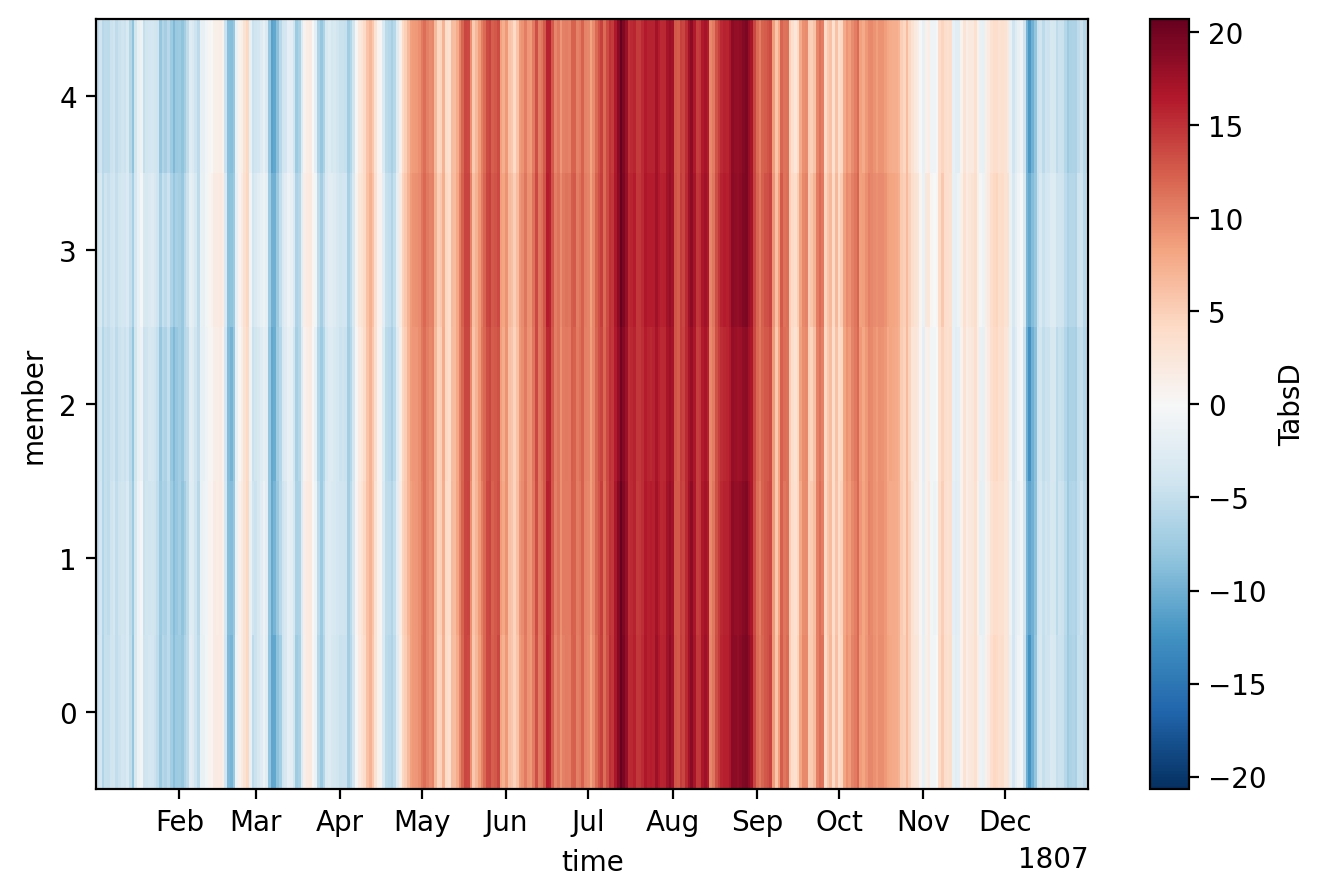

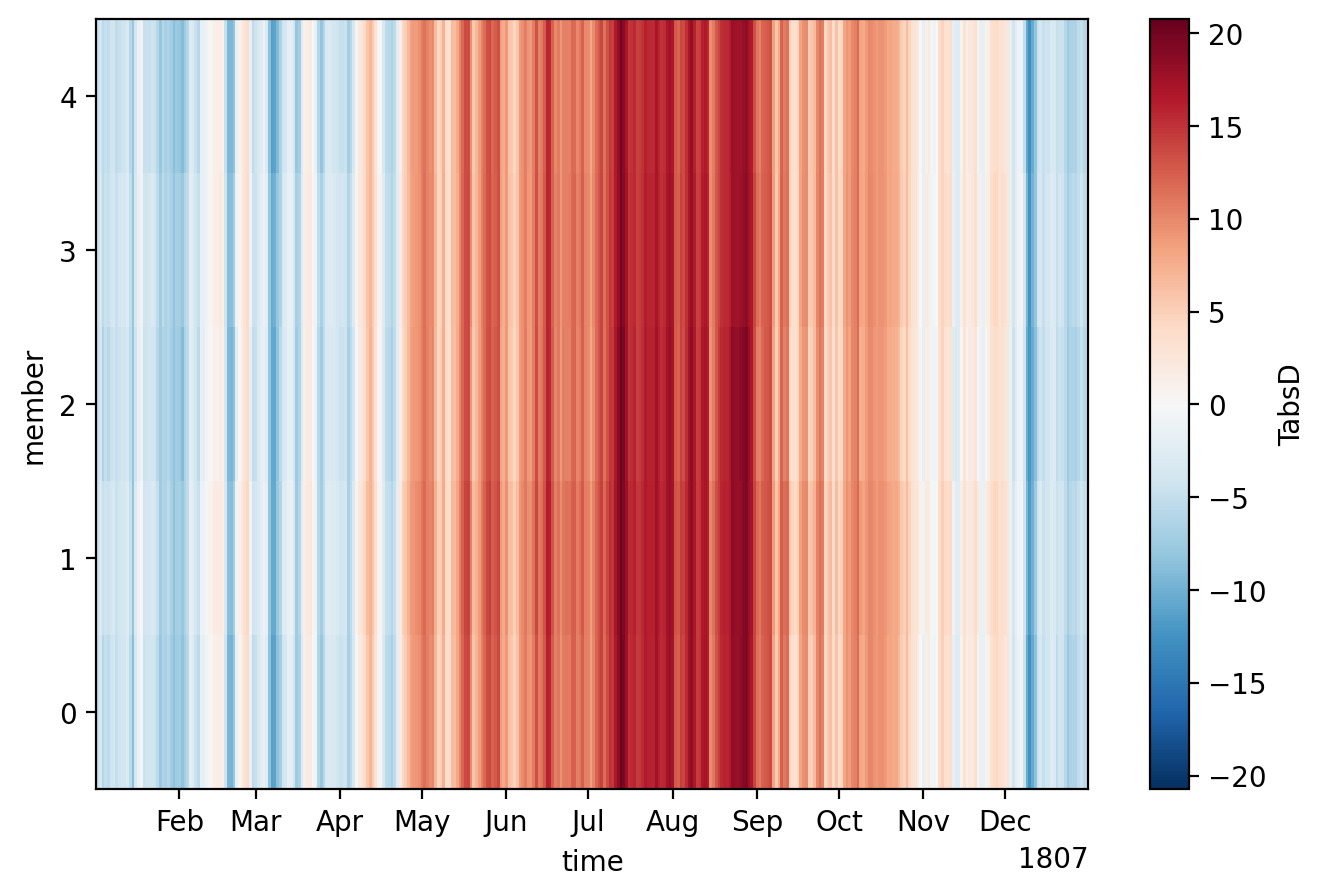

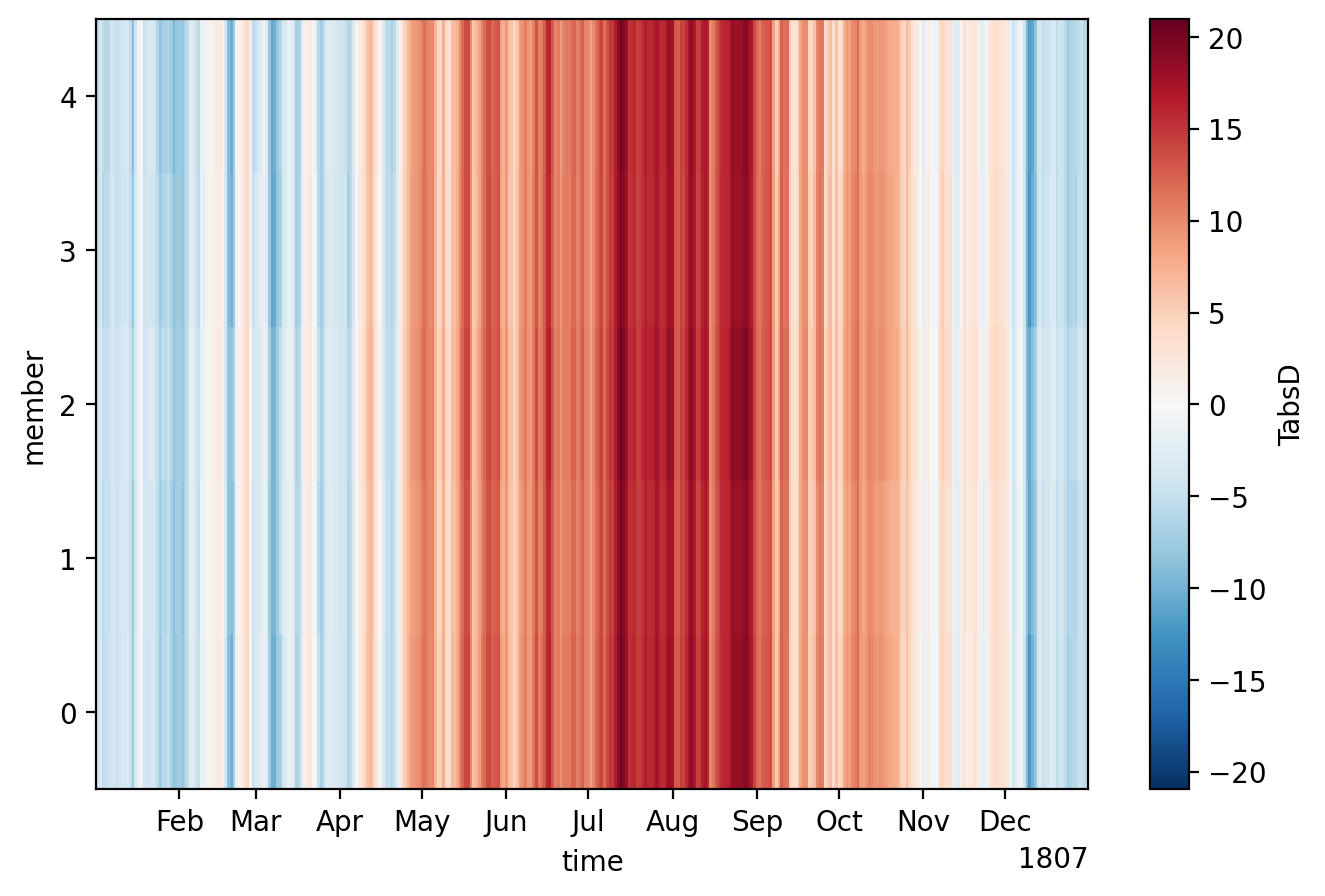

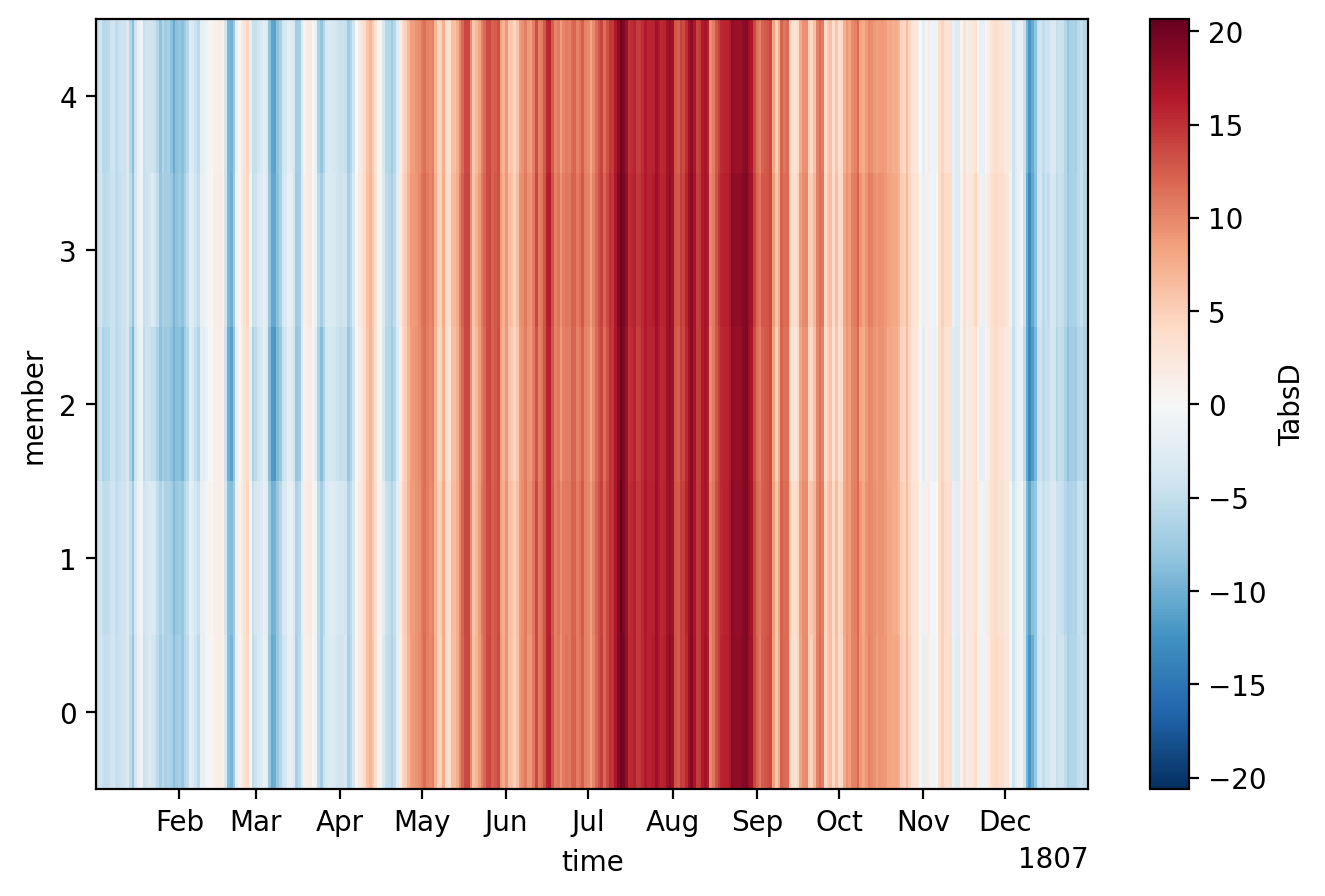

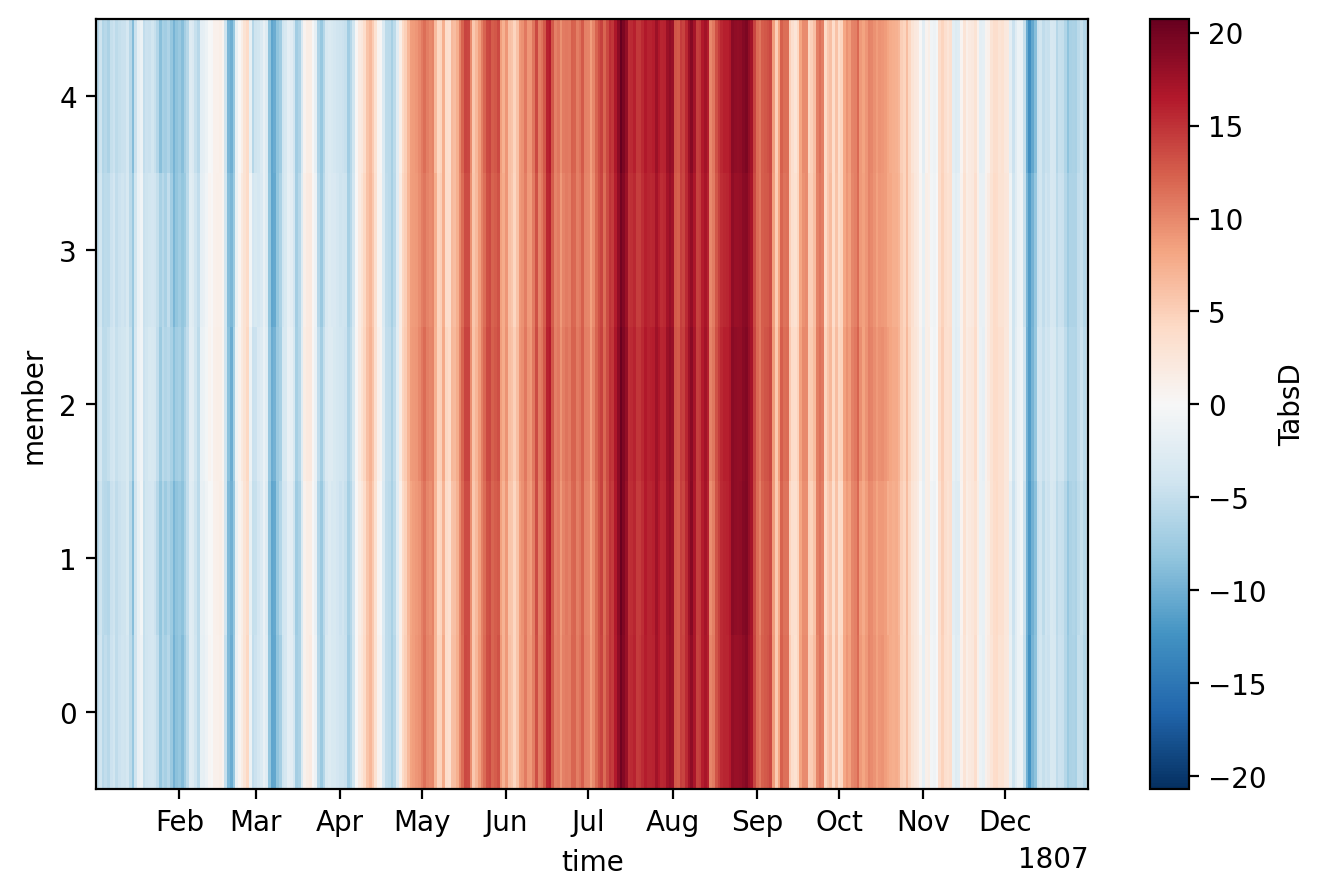

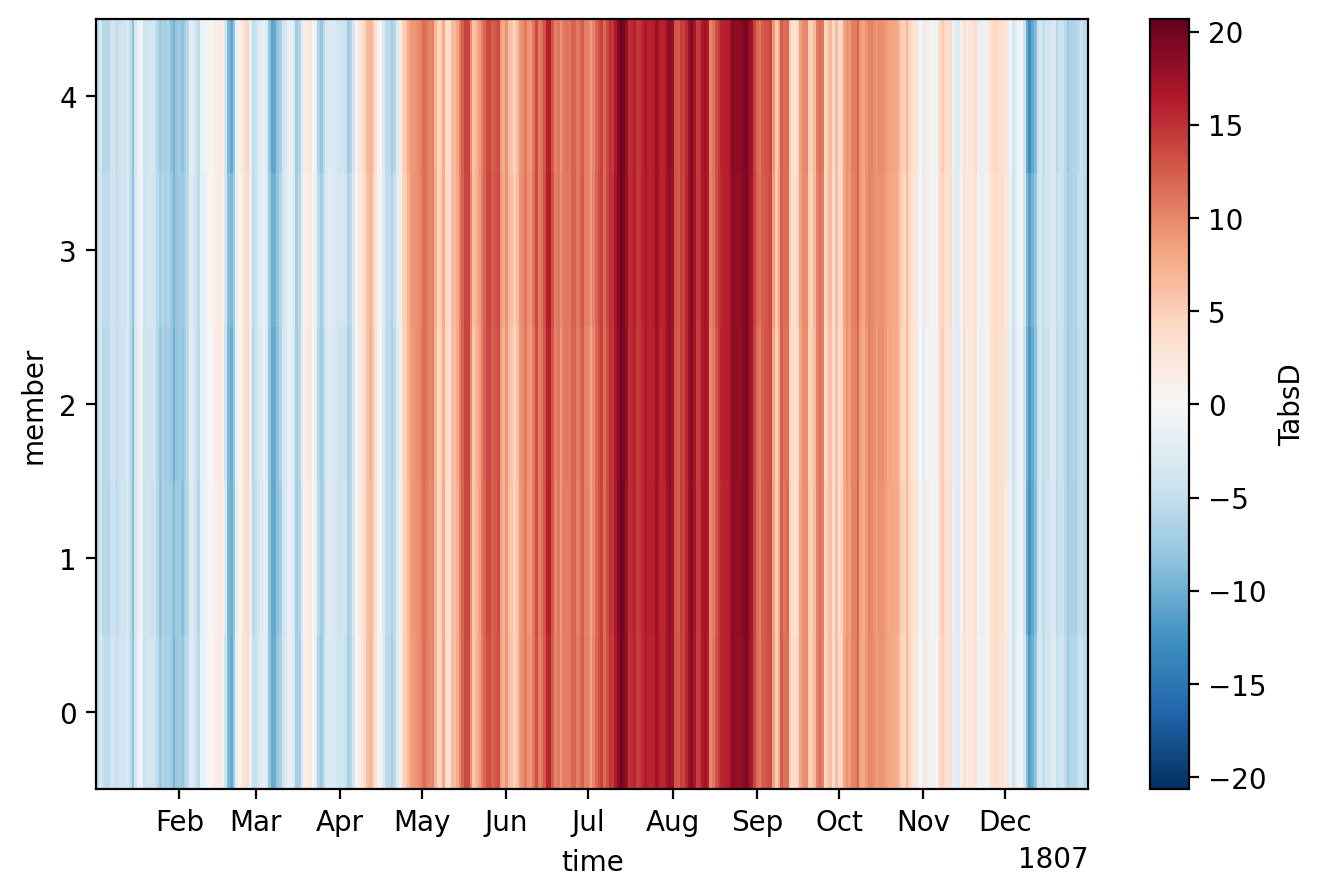

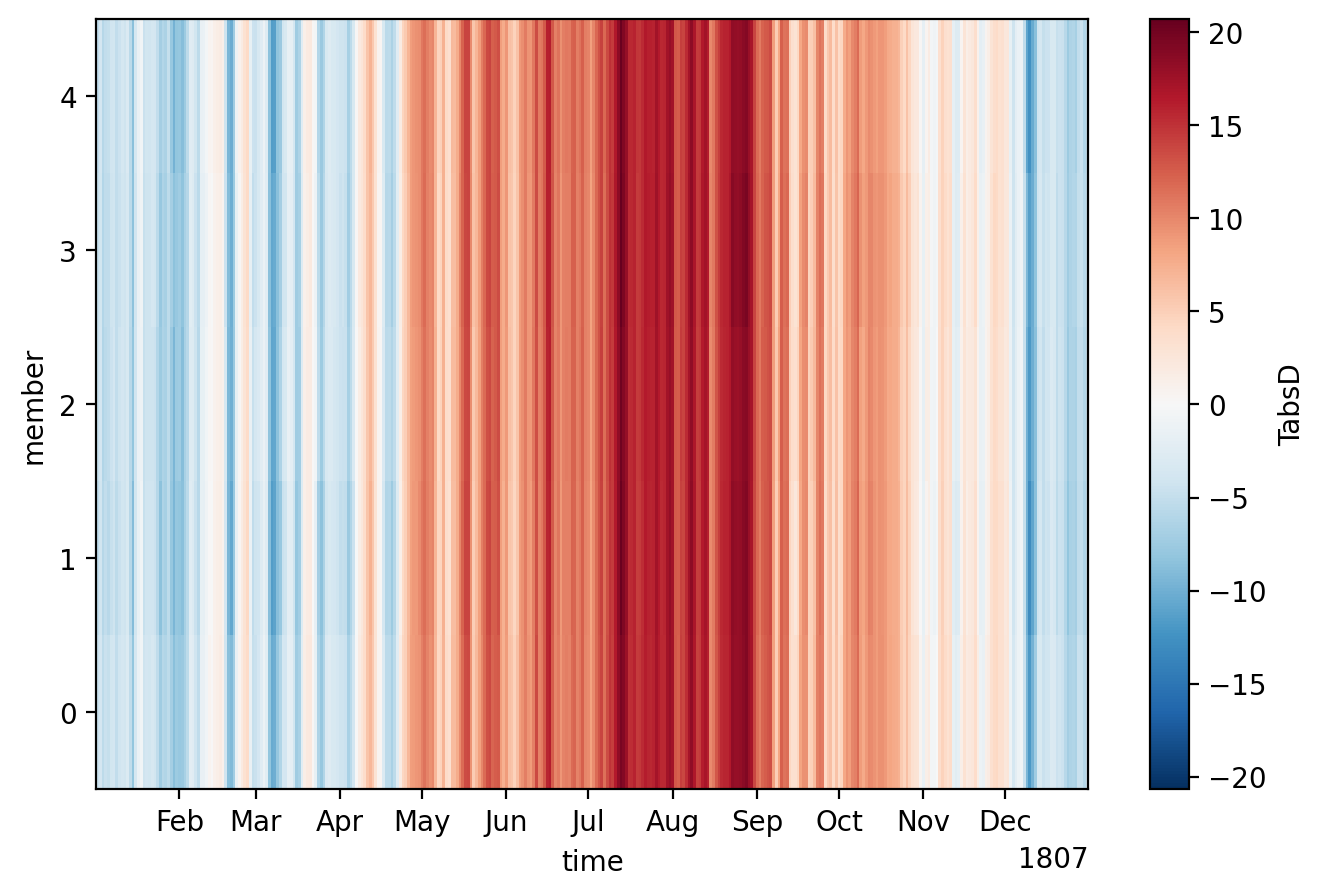

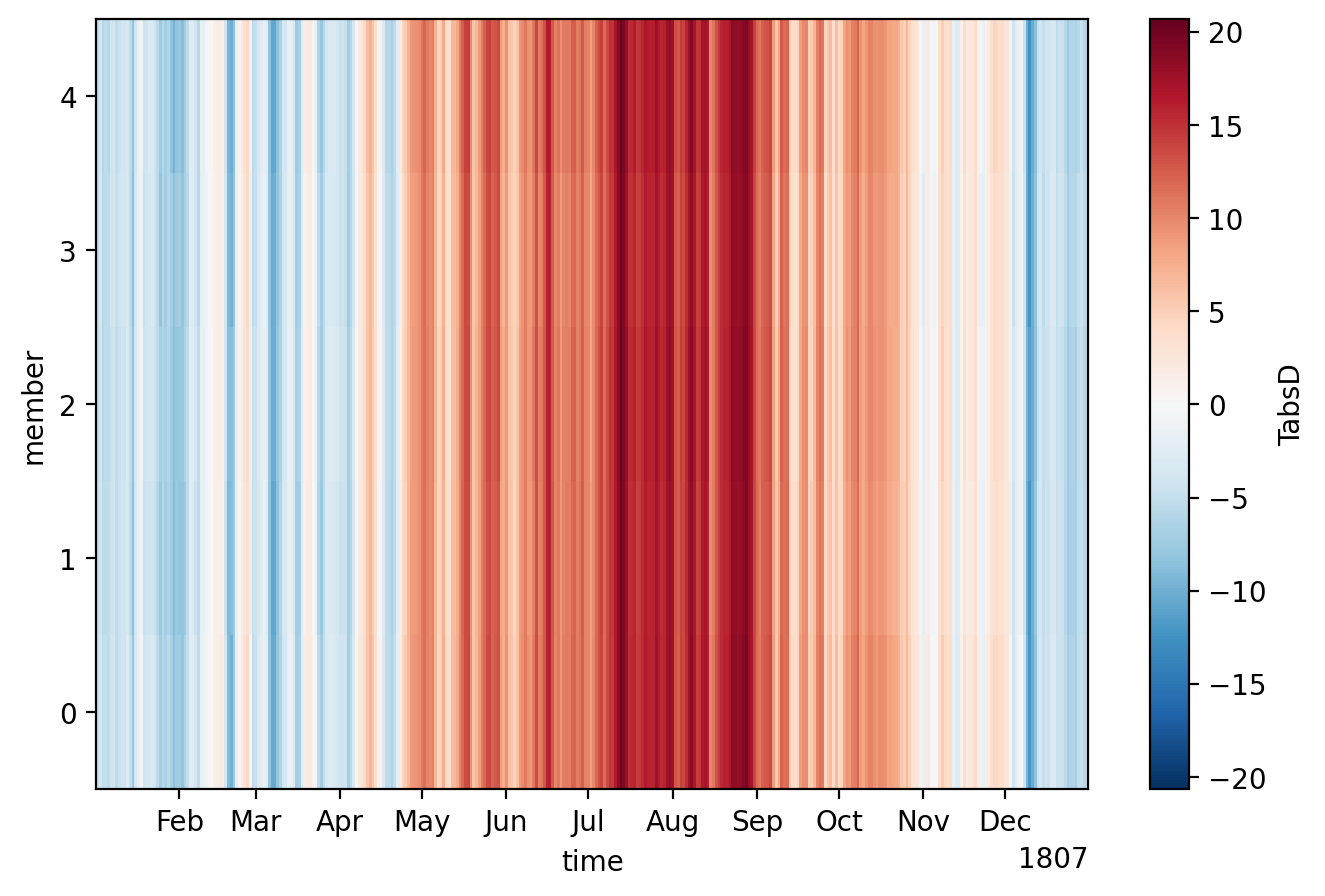

In [10]:
for rec in reconstruction_celsius_list:
    fig = plt.figure(figsize=(8, 5), dpi= 200)
    
    rec.mean(("E", "N")).plot()

In [11]:
ensemble=xr.concat(reconstruction_celsius_list,dim="member")

In [12]:
ensemble

<xarray.DataArray 'TabsD' (member: 40, time: 364, N: 240, E: 370)> Size: 5GB
dask.array<concatenate, shape=(40, 364, 240, 370), dtype=float32, chunksize=(1, 364, 240, 370), chunktype=numpy.ndarray>
Coordinates:
  * E        (E) float64 3kB 2.474e+06 2.476e+06 ... 2.842e+06 2.844e+06
  * N        (N) float64 2kB 1.064e+06 1.066e+06 ... 1.302e+06 1.304e+06
  * time     (time) datetime64[ns] 3kB 1807-01-02 1807-01-03 ... 1807-12-31
Dimensions without coordinates: member

In [13]:
enssize=ensemble.shape[0]

In [14]:
ensmed=ensemble.median(dim="member")

In [15]:
ensmean=ensemble.mean(dim="member")

# Vergleich

## 2D plots

### single time step

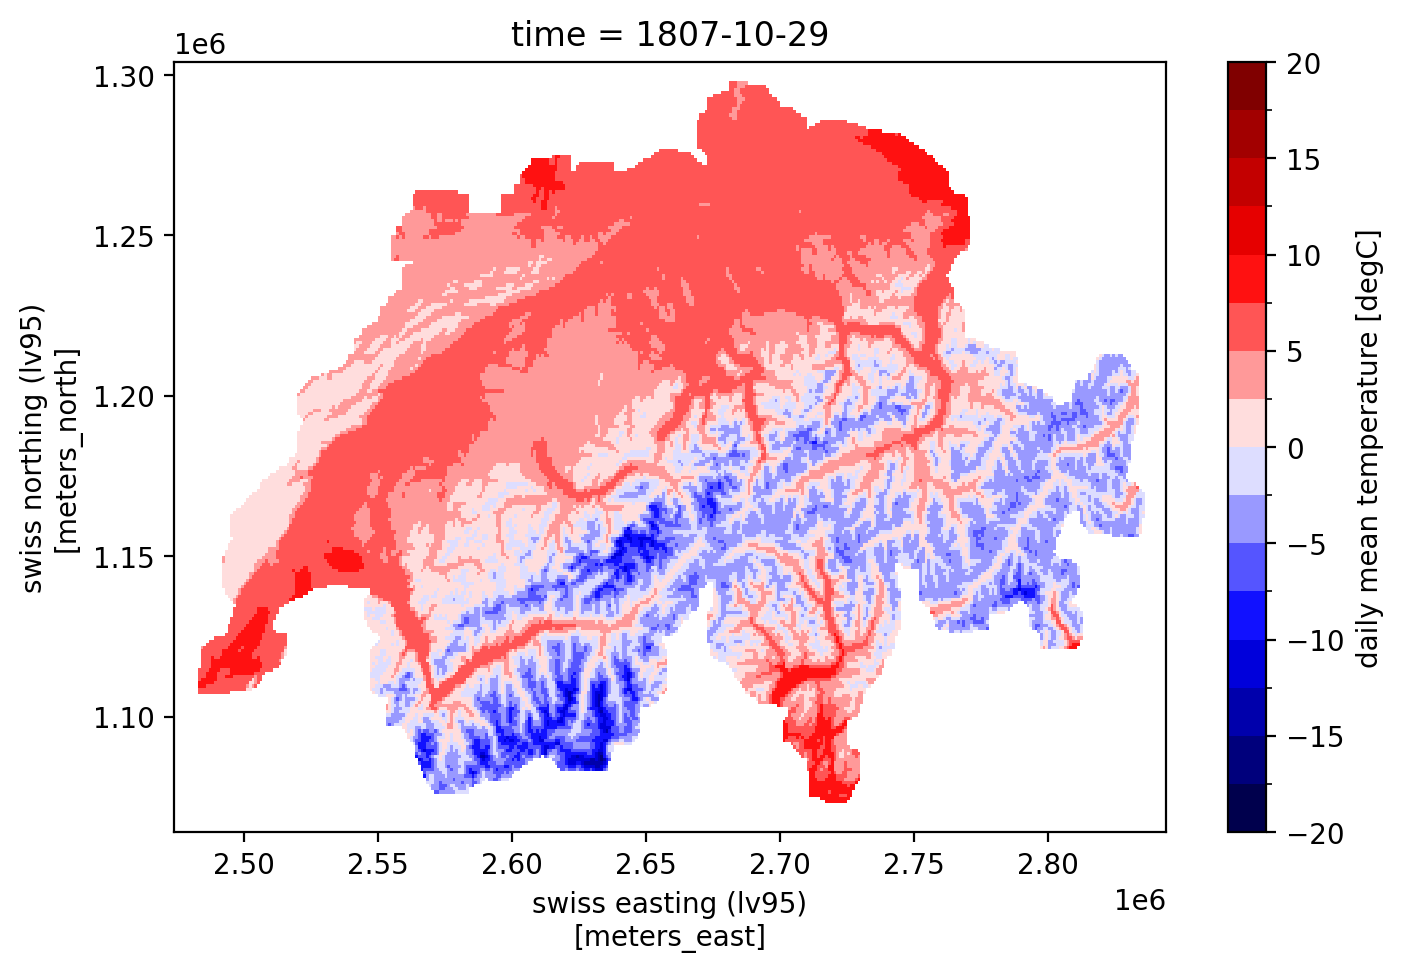

In [16]:
fig = plt.figure(figsize=(8, 5), dpi= 200)

noemi.isel(time=300).plot.pcolormesh(vmax=20,vmin=-20,cmap="seismic",levels = 17)

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/utils.py:73: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


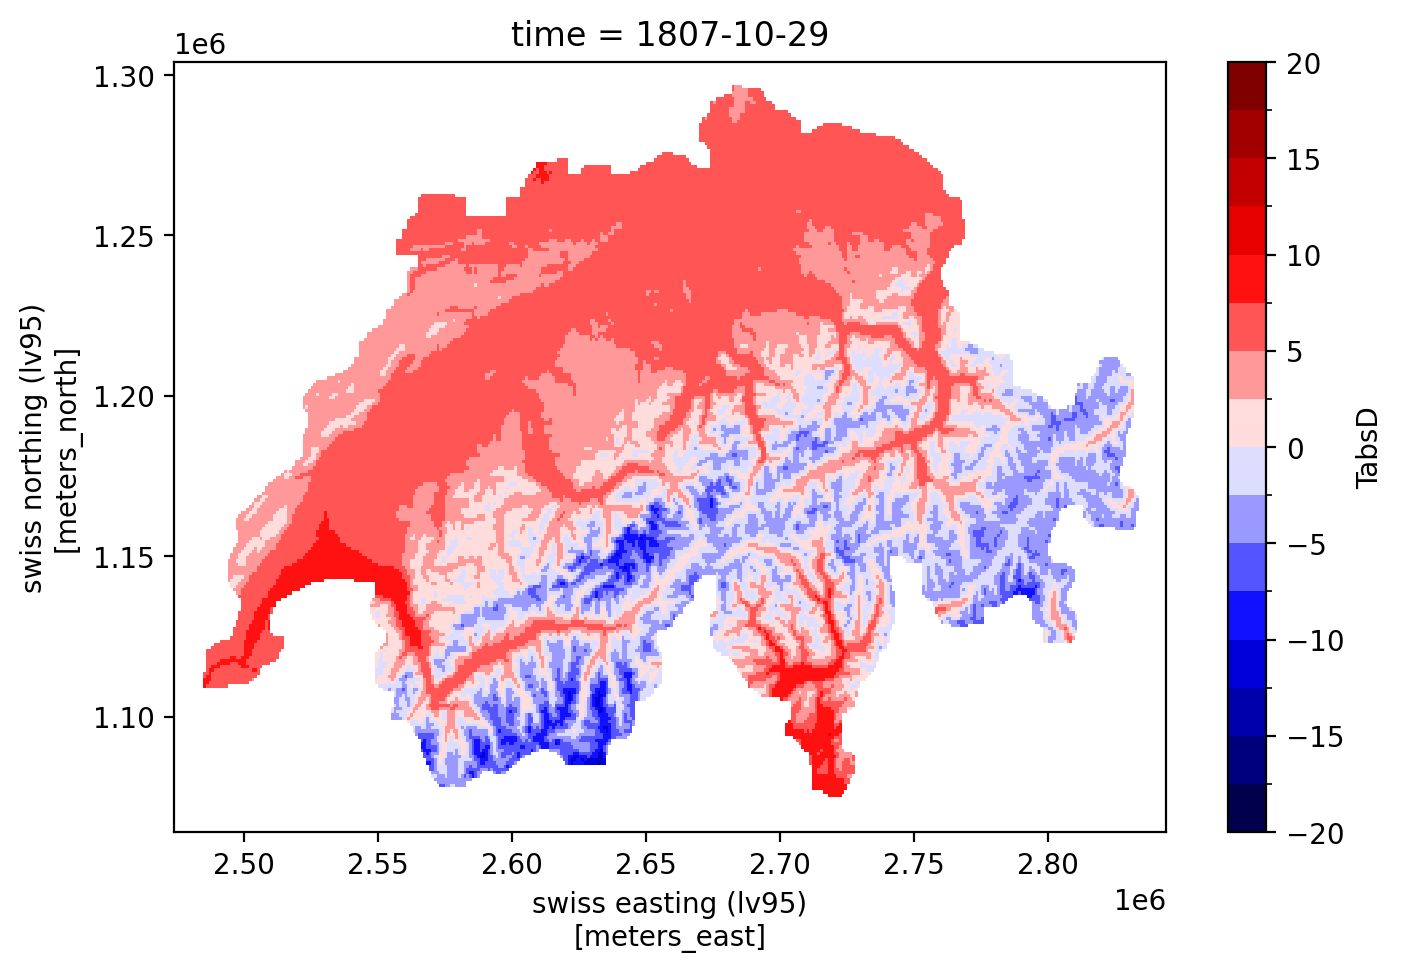

In [17]:
fig = plt.figure(figsize=(8, 5), dpi= 200)

ensmed.isel(time=300).plot.pcolormesh(vmax=20,vmin=-20,cmap="seismic",levels = 17)

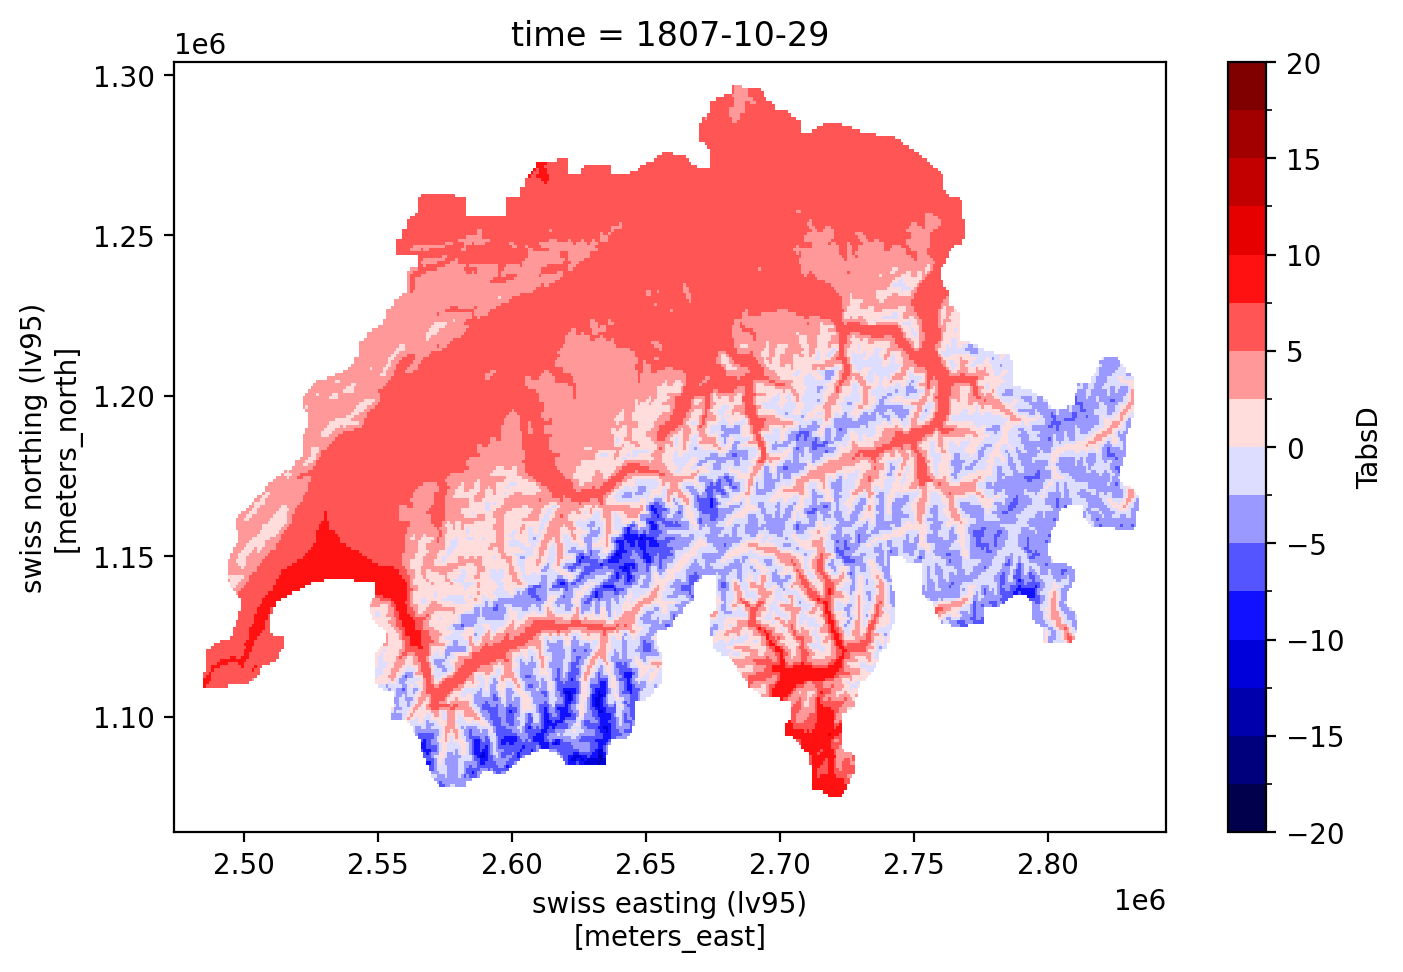

In [18]:
fig = plt.figure(figsize=(8, 5), dpi= 200)

ensmean.isel(time=300).plot.pcolormesh(vmax=20,vmin=-20,cmap="seismic",levels = 17)

### 1807 mean anomalies between Martin and Noemi

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/utils.py:73: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


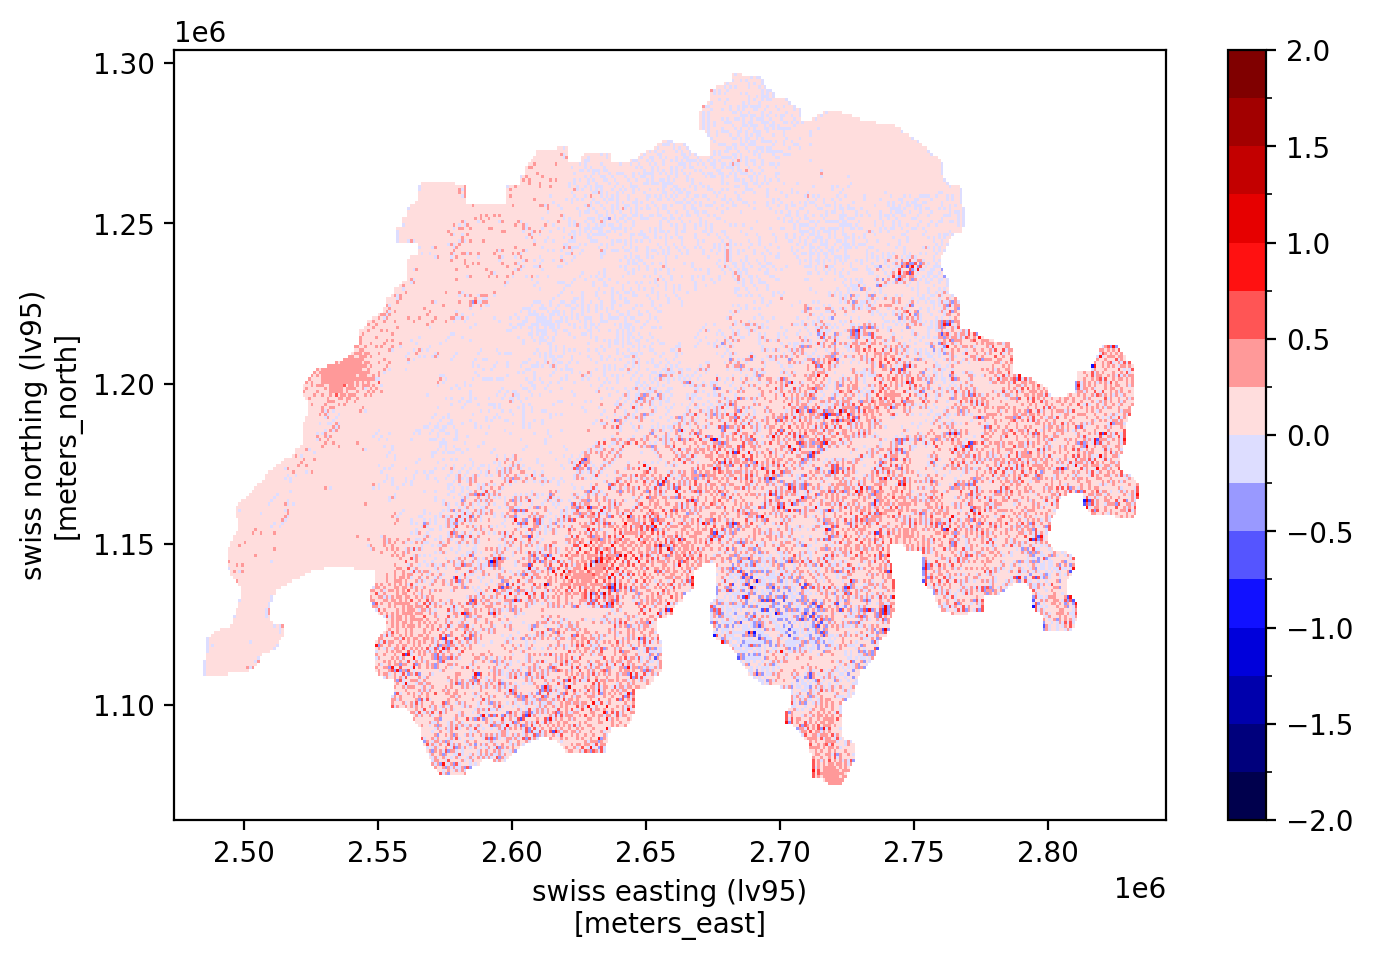

In [19]:
anoms_med=ensmed-noemi
anoms_med_mean=anoms_med.mean(dim="time")
fig = plt.figure(figsize=(8, 5), dpi= 200)

anoms_med_mean.plot.pcolormesh(vmax=2,vmin=-2,cmap="seismic",levels = 17)

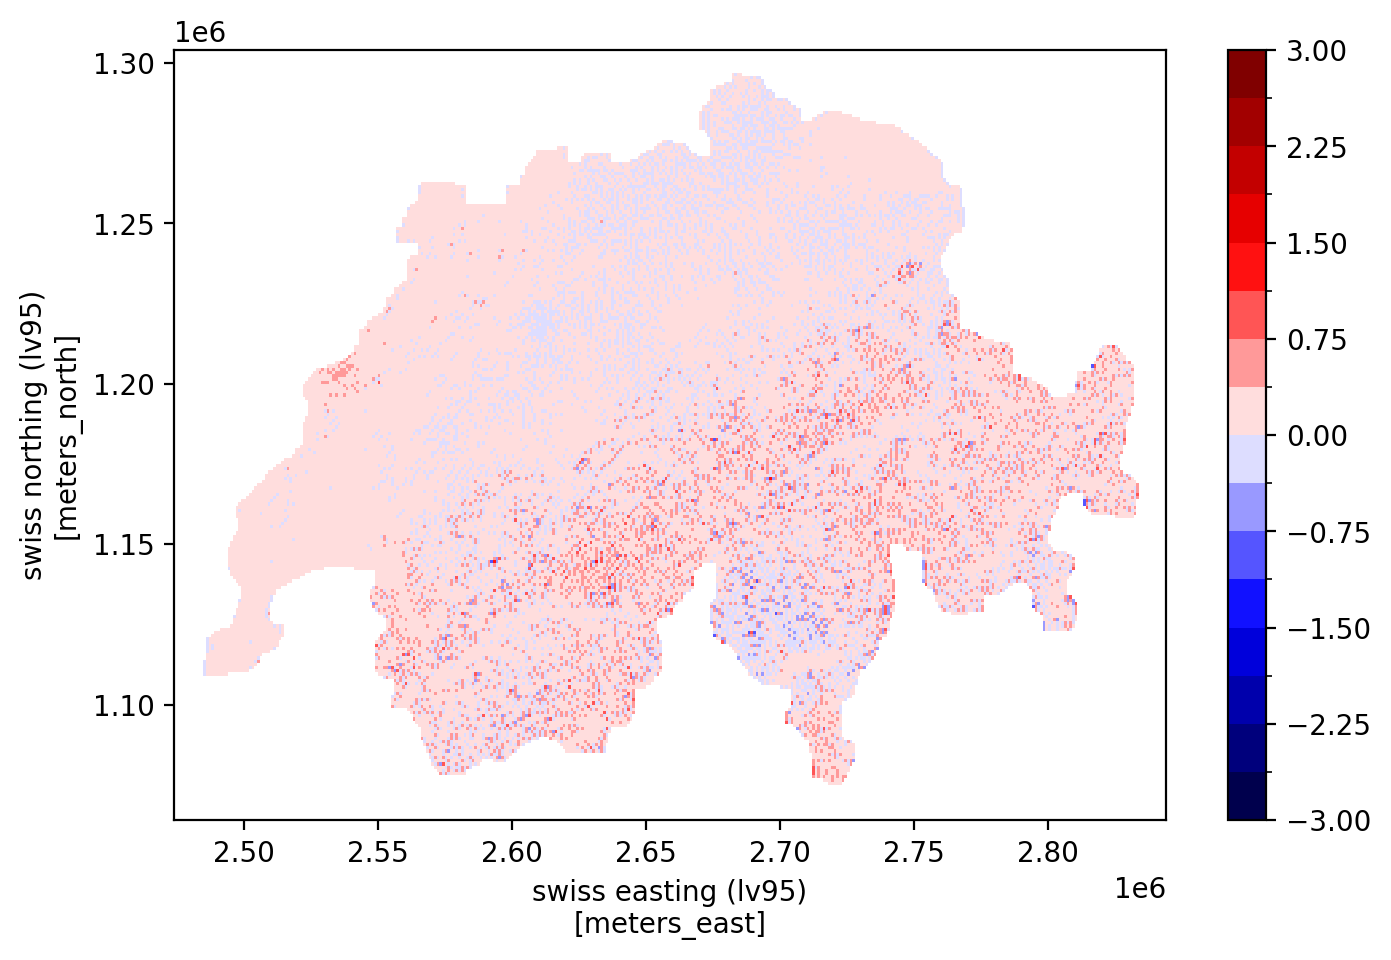

In [20]:
anoms_mean=ensmean-noemi
anoms_mean_mean=anoms_mean.mean(dim="time")
fig = plt.figure(figsize=(8, 5), dpi= 200)

anoms_mean_mean.plot.pcolormesh(vmax=3,vmin=-3,cmap="seismic",levels = 17)

### Correlation of daily values for 1807 between Martin and Noemi

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/utils.py:73: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


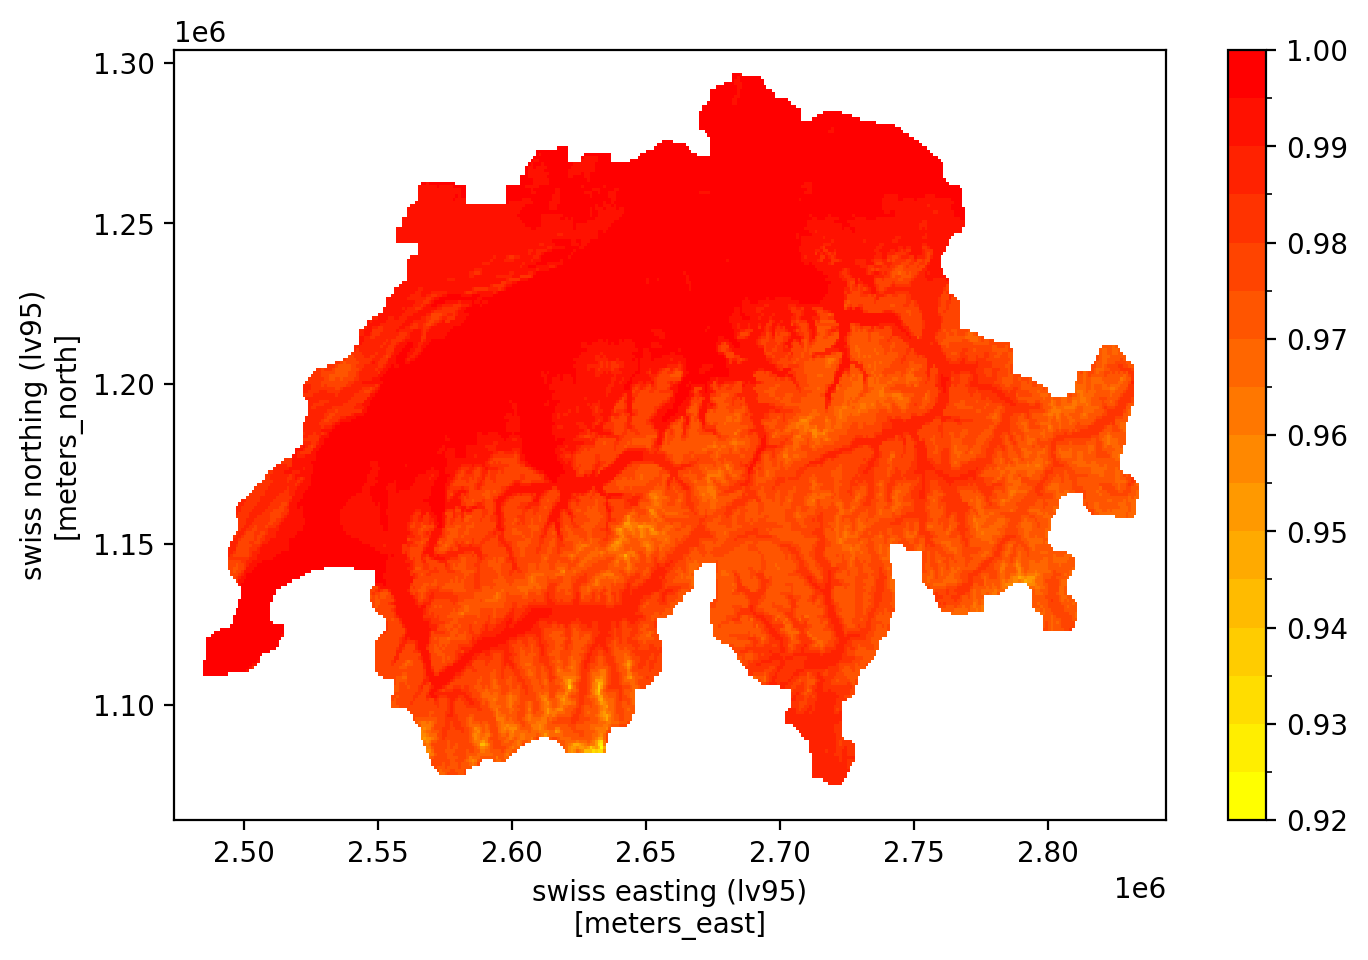

In [21]:
fig = plt.figure(figsize=(8, 5), dpi= 200)

xr.corr(ensmed,noemi,dim="time").plot.pcolormesh(cmap="autumn_r",levels = 17,vmax=1,vmin=0.92)

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


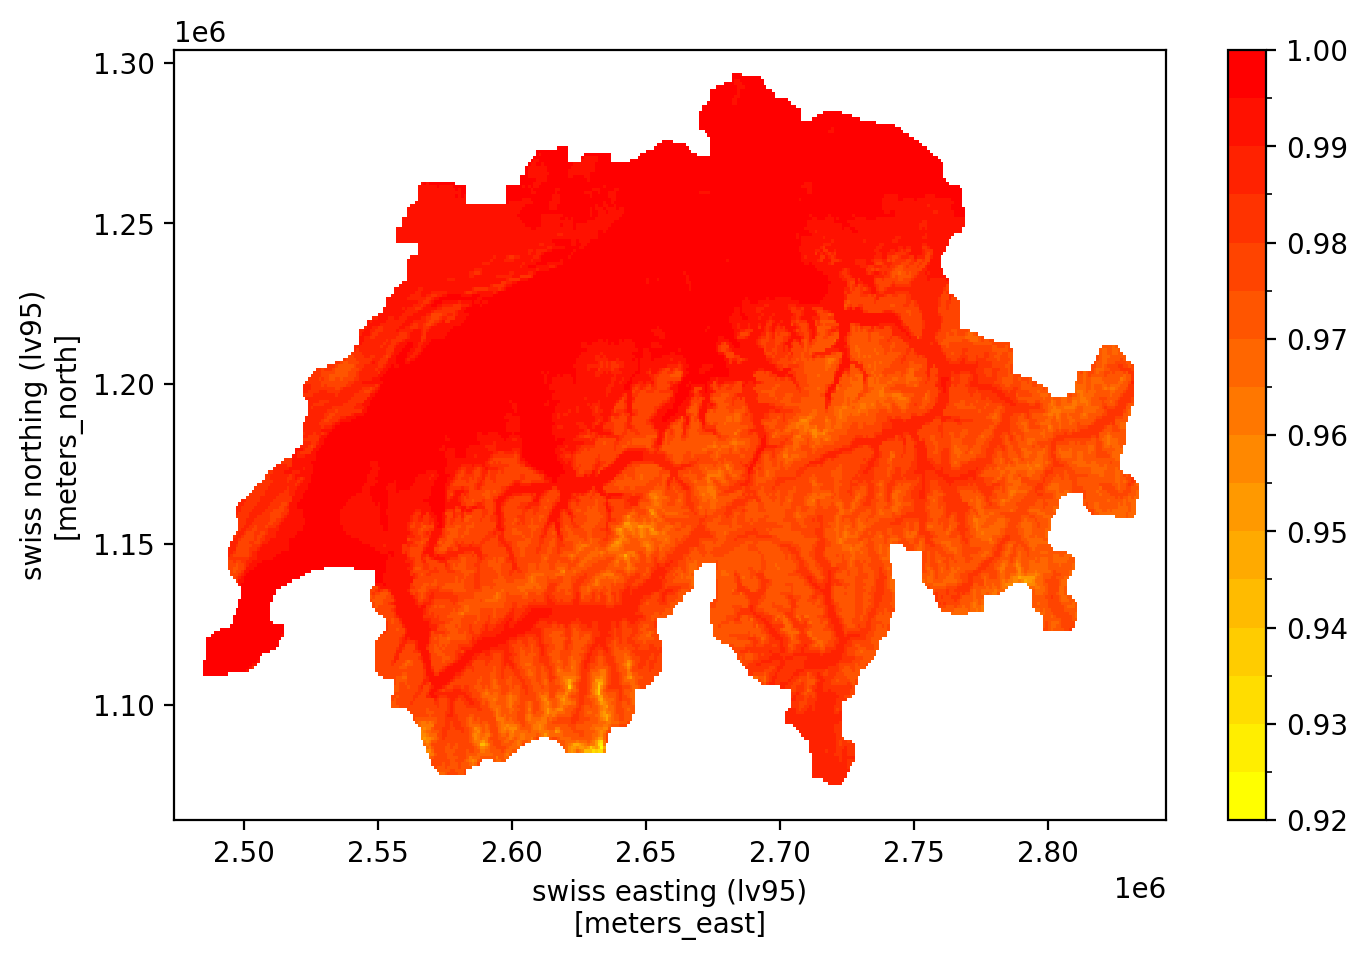

In [22]:
fig = plt.figure(figsize=(8, 5), dpi= 200)

xr.corr(ensmean,noemi,dim="time").plot.pcolormesh(cmap="autumn_r",levels = 17,vmax=1,vmin=0.92)

#### correlation in each member with Noemi

In [23]:
corrs_list=[]
for member in range(enssize):
    corrs_time=xr.corr(ensemble.isel(member=member),noemi,dim="time")
    print(corrs_time.mean(("E", "N")).values)
    corrs_list.append(corrs_time.mean(("E", "N")).values)

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


0.9836396


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


0.98413205


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


...

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


0.98375744


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


0.98391676


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


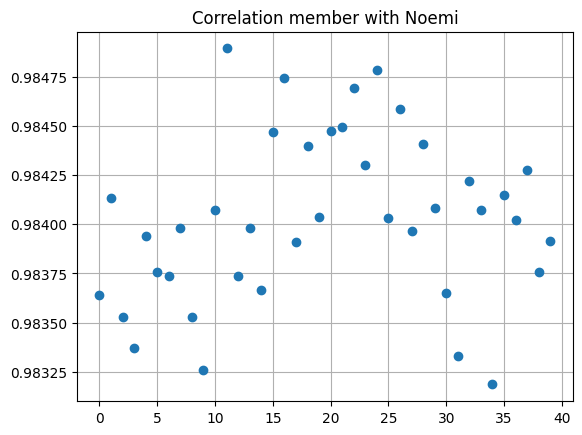

In [24]:
plt.plot(corrs_list,"o")
plt.title("Correlation member with Noemi")
plt.grid()

### RMSE in each member with Noemi

In [25]:
rmse_list=[]
for member in range(enssize):
    anoms=xs.rmse(ensemble.isel(member=member), noemi, dim='time')
    print(member)
    print(anoms.mean(("E", "N")).values)
    rmse_list.append(anoms.mean(("E", "N")).values)

0
1.4001919824017093
1
1.3821735872151883
2
1.391684444611898
3
1.505505666410207
4
1.3715931412576816
5
1.3885063600237453
6
1.4409689809211519
7
1.3863499575930243
8
1.4035261693261913
9
1.3962890933141447
10
1.3808579973580672
11
1.3532869747297591
12
1.4492758385606257
13
1.3543046366508318
14
1.3651074718714757
15
1.3576911664674076
16
1.3549214748240432
17
1.418093656444675
18
1.3595993690882455
19
1.361153064567592
20
1.341645842747553
21
1.3481931870706272
22
1.3599994595844458
23
1.342450506551298
24
1.3570350497457435
25
1.3482372252709038
26
1.3441593394210058
27
1.3635986053652298
28
1.3585404191415598
29
1.3782628200297742
30
1.404994271334829
31
1.4129612792645097
32
1.3605299722333906
33
1.3748561828066805
34
1.3883850664628714
35
1.3854108853302025
36
1.360590630471625
37
1.3623761603030151
38
1.3631796921302417
39
1.3983836802345557


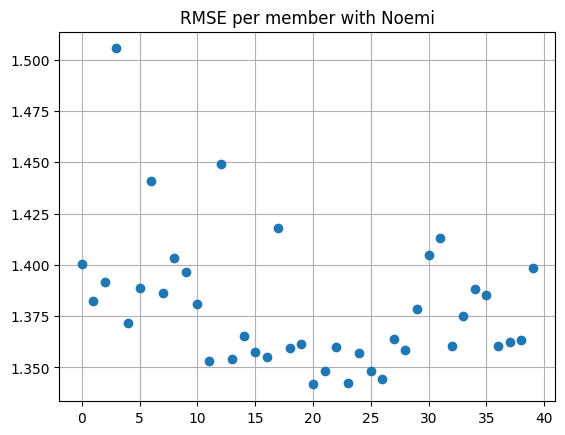

In [26]:
plt.plot(rmse_list,"o")
plt.title("RMSE per member with Noemi")
plt.grid()

### standard deviation over time differences Martin vs Noemi

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/utils.py:73: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/utils.py:73: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


array(-0.0584543, dtype=float32)

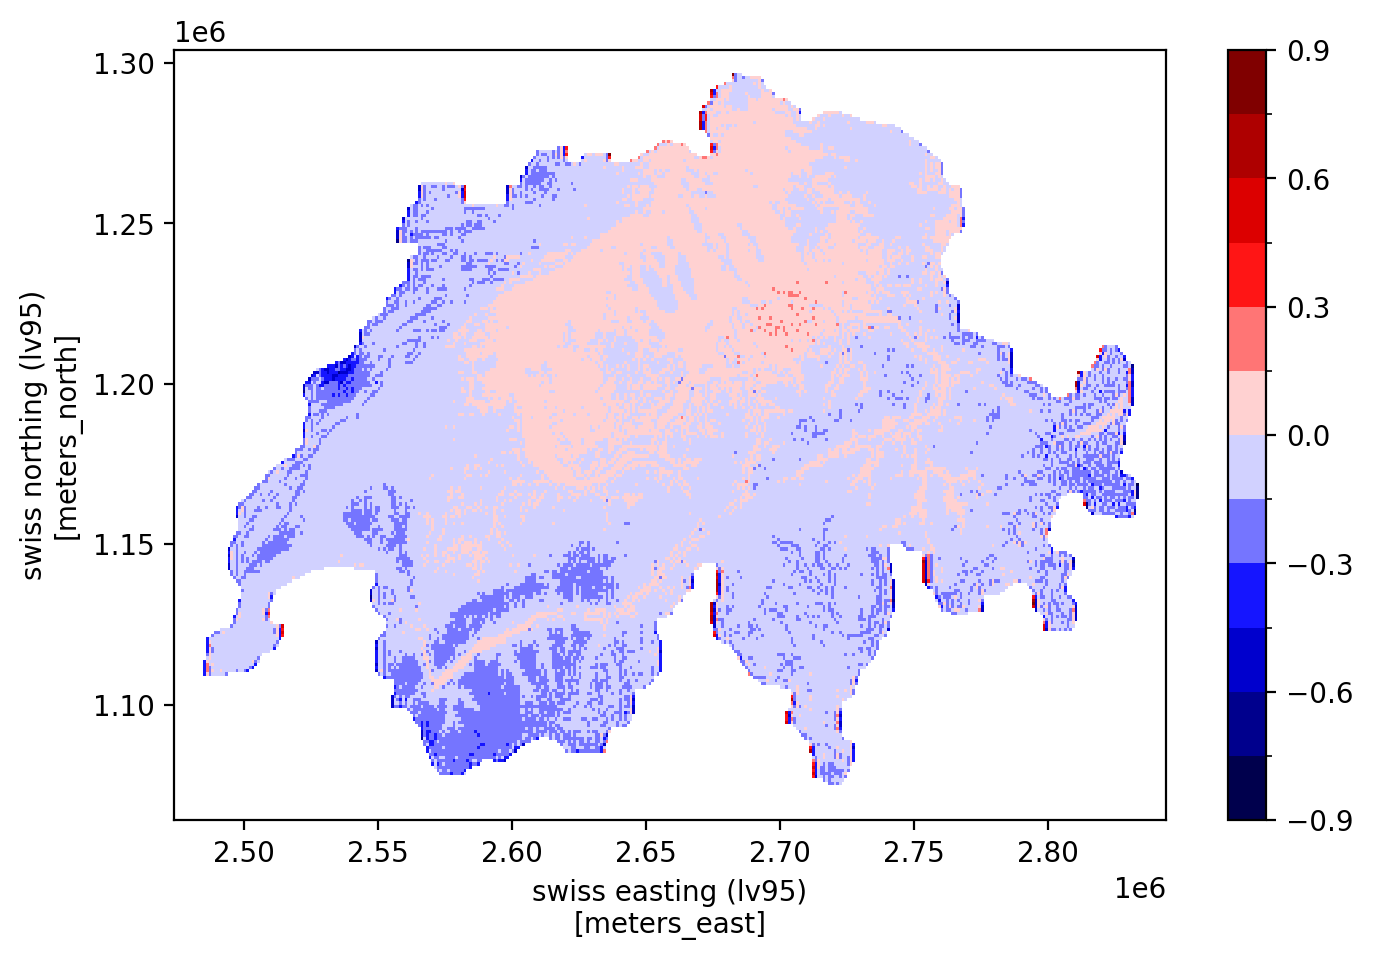

In [27]:
anoms_std=ensmed.std(dim="time")-noemi.std(dim="time")
fig = plt.figure(figsize=(8, 5), dpi= 200)
anoms_std.plot.pcolormesh(cmap="seismic",levels = 17)
anoms_std.mean().values

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


array(-0.06469137, dtype=float32)

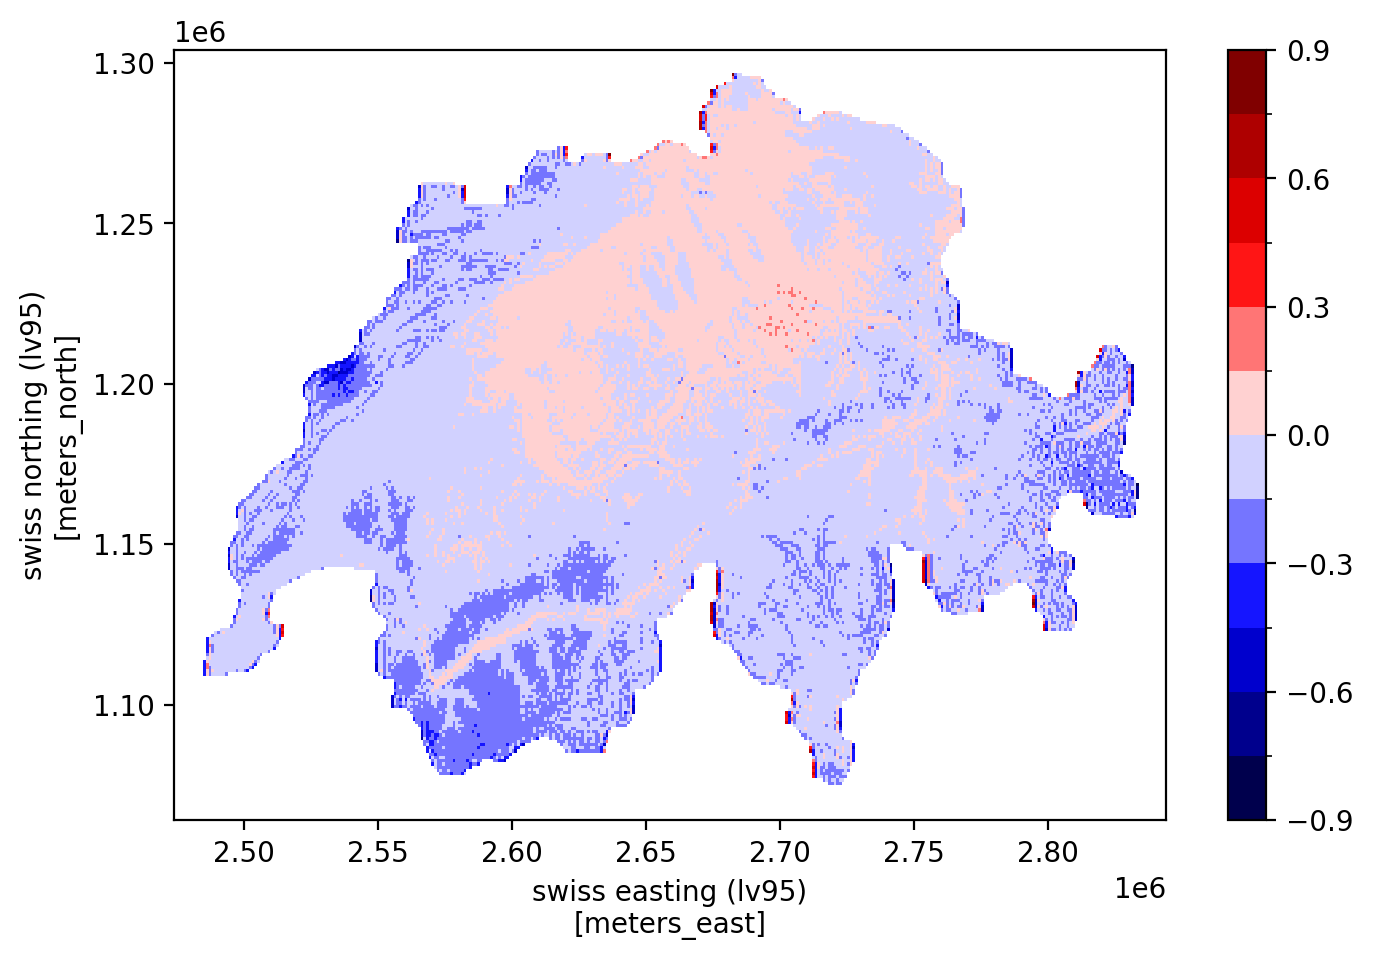

In [28]:
anoms_std=ensmean.std(dim="time")-noemi.std(dim="time")
fig = plt.figure(figsize=(8, 5), dpi= 200)
anoms_std.plot.pcolormesh(cmap="seismic",levels = 17)
anoms_std.mean().values

#### standard deviation over time differences Martin vs Noemi per member

In [29]:
diff_list=[]
for member in range(ensemble.shape[0]):
    anoms_std=ensemble.isel(member=member).std(dim="time")-noemi.std(dim="time")
    print(member)
    print(anoms_std.mean(("E", "N")).values)
    diff_list.append(anoms_std.mean(("E", "N")).values)

0


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


-0.014960186


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


1


...

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


39


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


0.098008186


/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


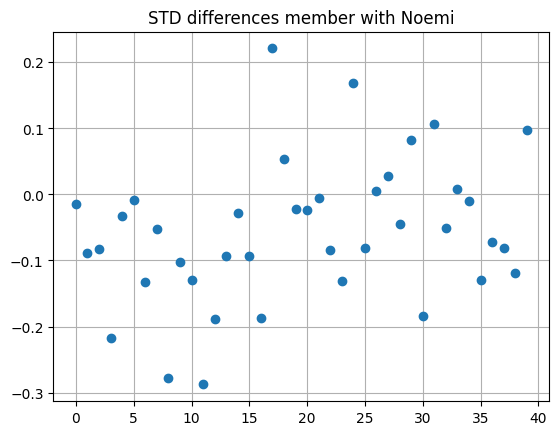

In [30]:
plt.plot(diff_list,"o")
plt.title("STD differences member with Noemi")
plt.grid()

## 1D plots

### Vergleich beider gegitterter Daten

#### Vergleich beider gegitterter Daten daily mean

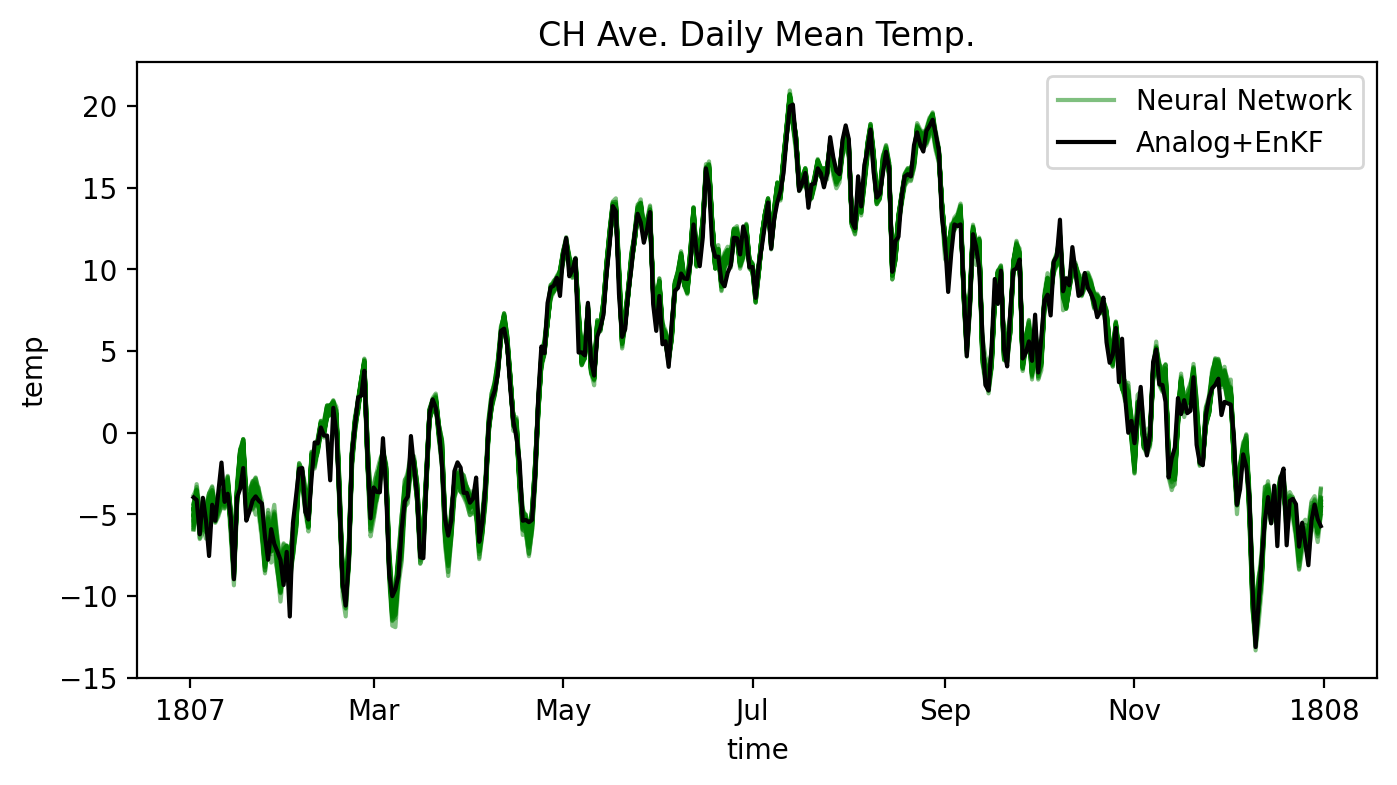

In [31]:
fig = plt.figure(figsize=(8, 4), dpi= 200)
#test.mean(("longitude", "latitude")).plot(label="NN")
for i in range(enssize):
    label = "Neural Network" if i == 0 else None
    ensemble.isel(member=i).mean(("E", "N")).plot(label=label,color="green",alpha=0.5)


noemi.mean(("E", "N")).plot(label="Analog+EnKF",color="black")
plt.title("CH Ave. Daily Mean Temp.")
plt.legend()


#### Vergleich beider gegitterter Daten daily min

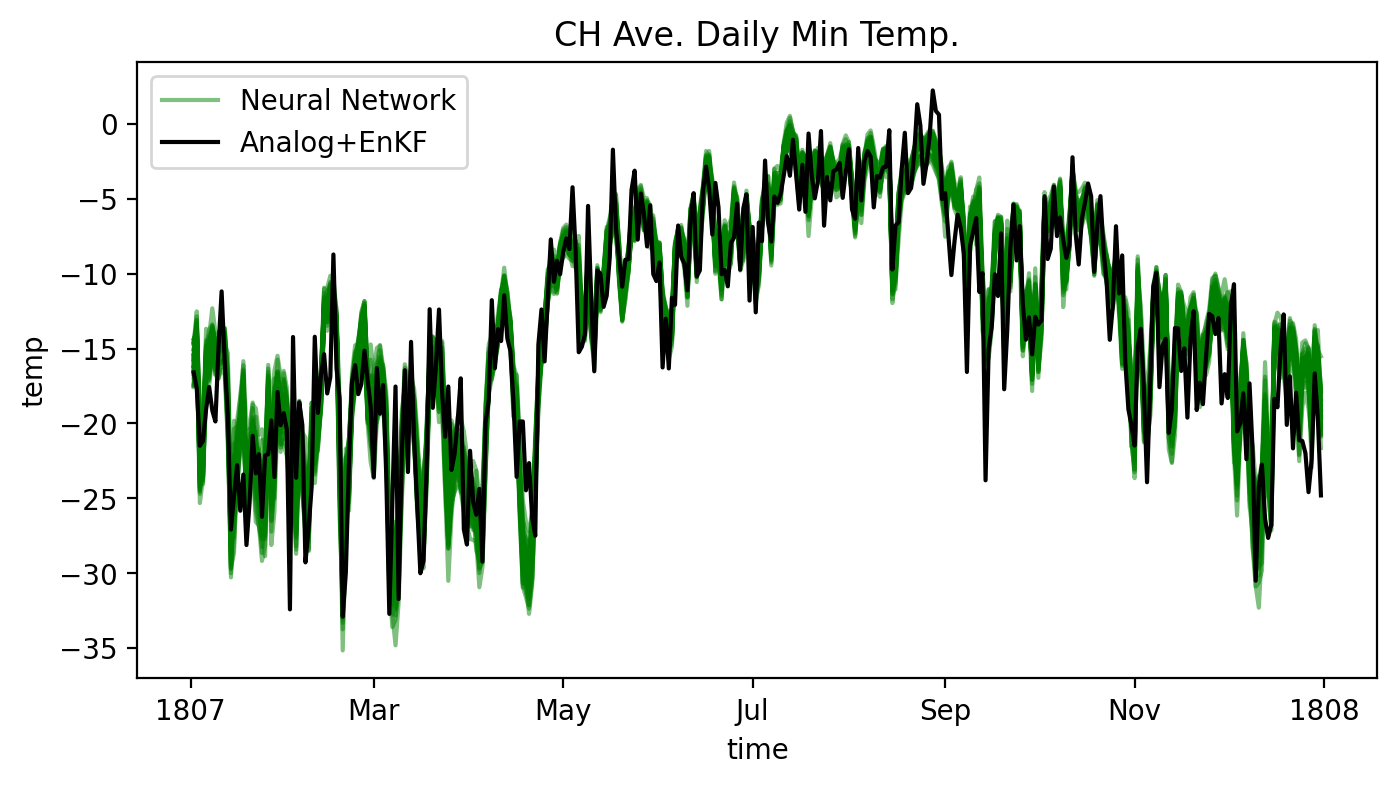

In [32]:
fig = plt.figure(figsize=(8, 4), dpi= 200)
#test.mean(("longitude", "latitude")).plot(label="NN")
for i in range(enssize):
    label = "Neural Network" if i == 0 else None
    ensemble.isel(member=i).min(("E", "N")).plot(label=label,color="green",alpha=0.5)


noemi.min(("E", "N")).plot(label="Analog+EnKF",color="black")
plt.title("CH Ave. Daily Min Temp.")
plt.legend()


#### Vergleich beider gegitterter Daten daily max

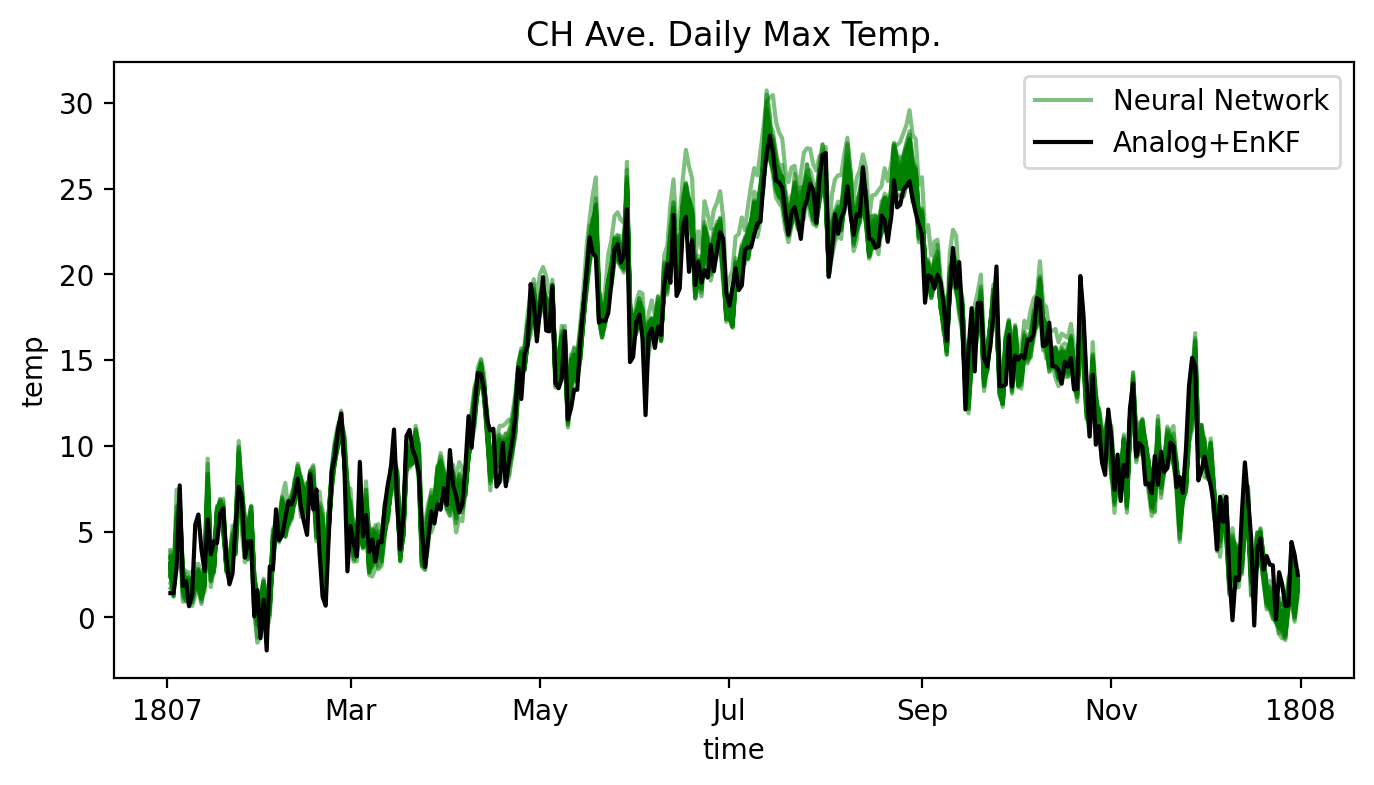

In [33]:
fig = plt.figure(figsize=(8, 4), dpi= 200)
#test.mean(("longitude", "latitude")).plot(label="NN")
#ensmed.max(("E", "N")).plot(color="green",alpha=0.5,label="Neural Network")
for i in range(enssize):
    label = "Neural Network" if i == 0 else None
    ensemble.isel(member=i).max(("E", "N")).plot(label=label,color="green",alpha=0.5)


noemi.max(("E", "N")).plot(label="Analog+EnKF",color="black")
plt.title("CH Ave. Daily Max Temp.")
plt.legend()


#### Vergleich beider gegitterter Daten daily std

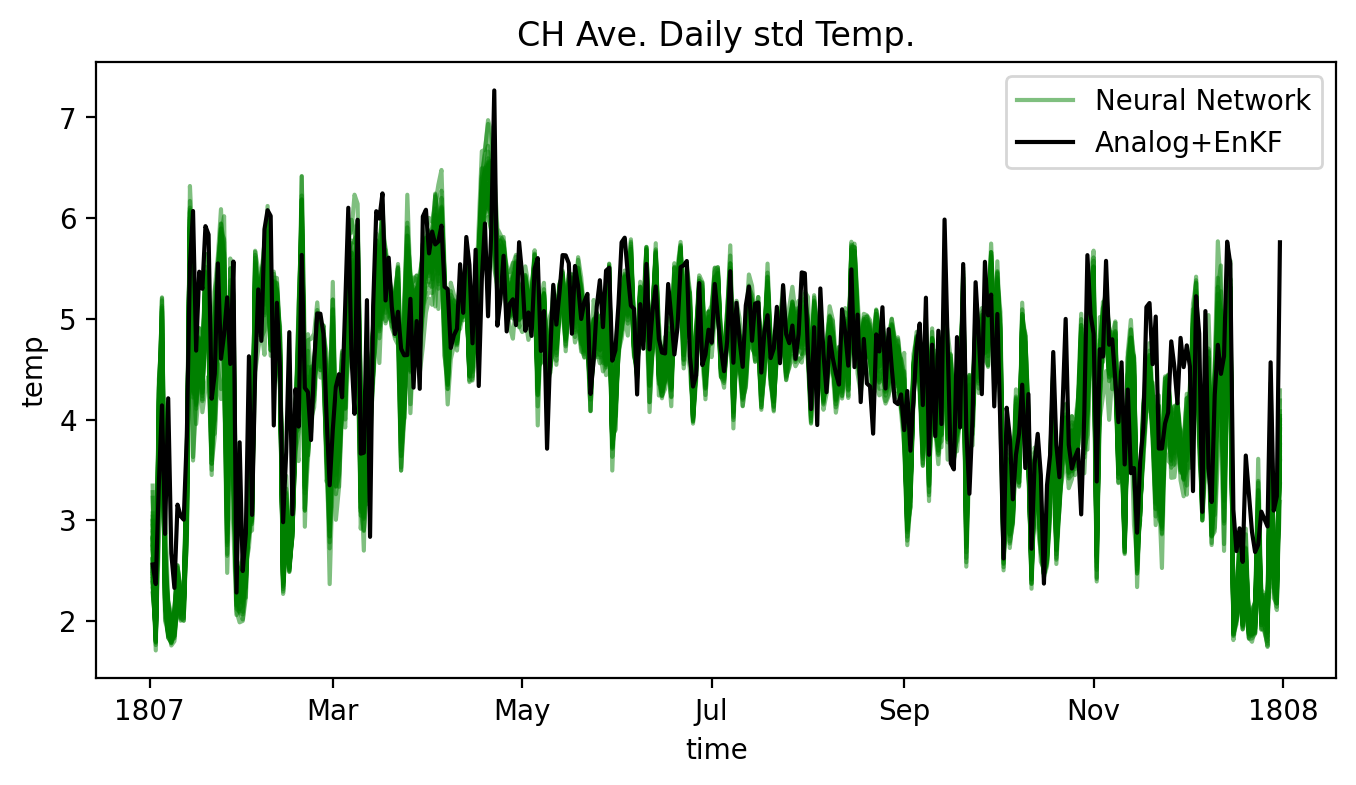

In [34]:
fig = plt.figure(figsize=(8, 4), dpi= 200)
#test.mean(("longitude", "latitude")).plot(label="NN")
for i in range(enssize):
    label = "Neural Network" if i == 0 else None
    ensemble.isel(member=i).std(("E", "N")).plot(label=label,color="green",alpha=0.5)


noemi.std(("E", "N")).plot(label="Analog+EnKF",color="black")
plt.title("CH Ave. Daily std Temp.")
plt.legend()


#### Vergleich beider gegitterter Daten daily corr

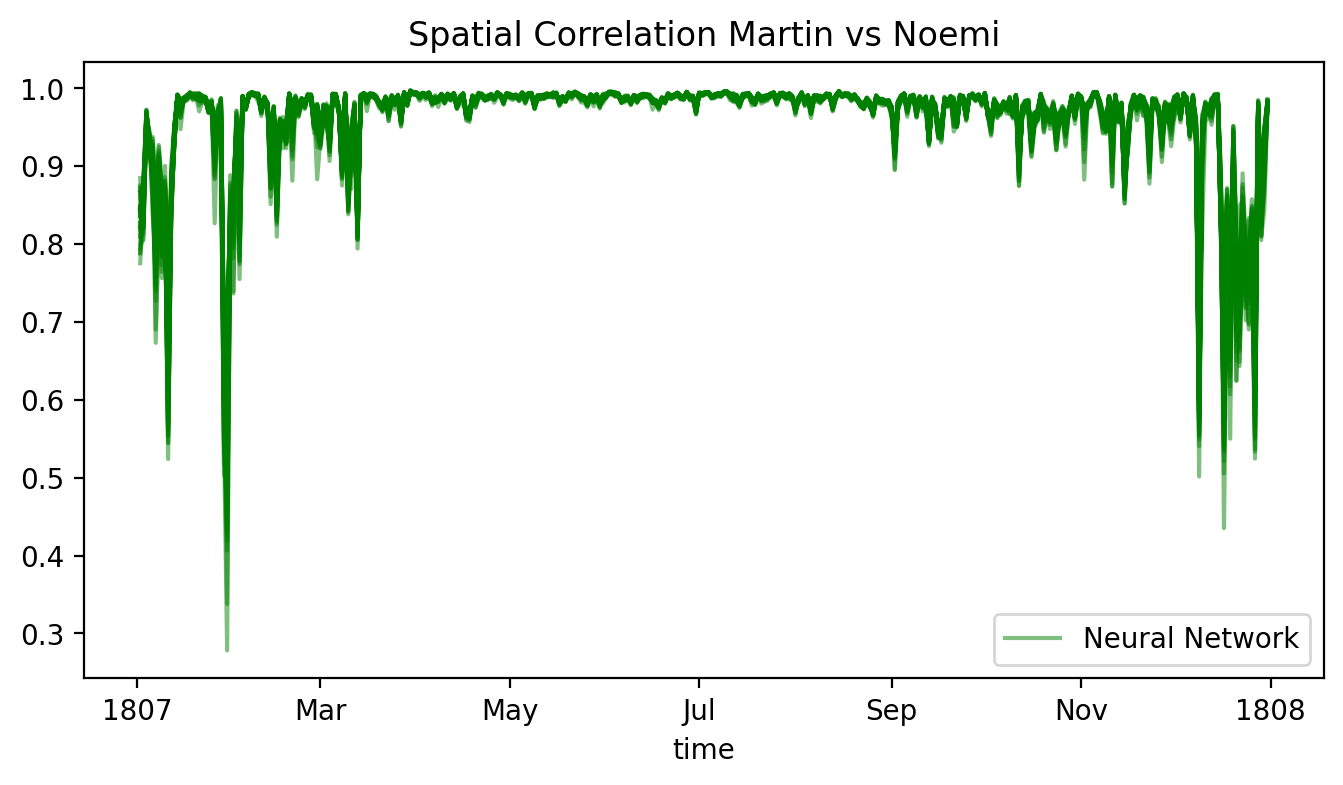

In [35]:
fig = plt.figure(figsize=(8, 4), dpi= 200)
#test.mean(("longitude", "latitude")).plot(label="NN")
for i in range(enssize):
    label = "Neural Network" if i == 0 else None
    xr.corr(ensemble.isel(member=i),noemi,dim=("E", "N")).plot(label=label,color="green",alpha=0.5)


plt.title("Spatial Correlation Martin vs Noemi")
plt.legend()


### Vergleich mit unabhängigen in-situ daten

In [36]:
GCOS_Zurich_Feer = pd.read_csv("/Users/mwegmann/Dropbox/SPARK_WINTER/PALAEO-RA_GCOS_Zurich_Feer_18070101-18271231_ta_daily_modified.tsv", delimiter = ",")


In [37]:
GCOS_Zurich_Feer_1807 = GCOS_Zurich_Feer[GCOS_Zurich_Feer['Year'] == 1807].copy()


In [38]:
GCOS_Zurich_Feer_1807

,Year,Month,Day,Hour,Minute,Period,Value,Meta
0,1807,1,1,24,0,day,0.5,n.obs=3|n.times=3
1,1807,1,2,24,0,day,-2.5,n.obs=3|n.times=3
2,1807,1,3,24,0,day,-2.4,n.obs=3|n.times=3
3,1807,1,4,24,0,day,-2.6,n.obs=1|n.times=1
4,1807,1,5,24,0,day,-9999.0,n.obs=1|n.times=1
...,...,...,...,...,...,...,...,...
328,1807,12,27,24,0,day,-4.9,n.obs=3|n.times=3
329,1807,12,28,24,0,day,0.8,n.obs=2|n.times=2
330,1807,12,29,24,0,day,-4.0,n.obs=3|n.times=3
331,1807,12,30,24,0,day,-4.1,n.obs=3|n.times=3


In [39]:
# Combine the columns into a datetime column
GCOS_Zurich_Feer_1807['Datetime'] = pd.to_datetime(GCOS_Zurich_Feer_1807[['Year', 'Month', 'Day']])

# Set this new column as the DataFrame index
GCOS_Zurich_Feer_1807.set_index('Datetime', inplace=True)


In [40]:
GCOS_Zurich_Feer_1807['Value'] = GCOS_Zurich_Feer_1807['Value'].replace(-9999, np.nan)

In [41]:
GCOS_Zurich_Feer_1807

,Year,Month,Day,Hour,Minute,Period,Value,Meta
Datetime,,,,,,,,
1807-01-01,1807,1,1,24,0,day,0.5,n.obs=3|n.times=3
1807-01-02,1807,1,2,24,0,day,-2.5,n.obs=3|n.times=3
1807-01-03,1807,1,3,24,0,day,-2.4,n.obs=3|n.times=3
1807-01-04,1807,1,4,24,0,day,-2.6,n.obs=1|n.times=1
1807-01-05,1807,1,5,24,0,day,NaN,n.obs=1|n.times=1
...,...,...,...,...,...,...,...,...
1807-12-27,1807,12,27,24,0,day,-4.9,n.obs=3|n.times=3
1807-12-28,1807,12,28,24,0,day,0.8,n.obs=2|n.times=2
1807-12-29,1807,12,29,24,0,day,-4.0,n.obs=3|n.times=3


In [42]:
GCOS_Zurich_Feer_1807_time=GCOS_Zurich_Feer_1807.index

In [43]:
common_times = np.intersect1d(noemi.sel(E=2683484.331,N=1247341.058,method="nearest").time.values, GCOS_Zurich_Feer_1807_time.astype('datetime64[ns]').values)

In [44]:
GCOS_Zurich_Feer_1807_intersection = GCOS_Zurich_Feer_1807.loc[common_times]

In [45]:
GCOS_Zurich_Feer_1807_intersection

,Year,Month,Day,Hour,Minute,Period,Value,Meta
Datetime,,,,,,,,
1807-01-02,1807,1,2,24,0,day,-2.5,n.obs=3|n.times=3
1807-01-03,1807,1,3,24,0,day,-2.4,n.obs=3|n.times=3
1807-01-04,1807,1,4,24,0,day,-2.6,n.obs=1|n.times=1
1807-01-05,1807,1,5,24,0,day,NaN,n.obs=1|n.times=1
1807-01-06,1807,1,6,24,0,day,-1.5,n.obs=2|n.times=2
...,...,...,...,...,...,...,...,...
1807-12-27,1807,12,27,24,0,day,-4.9,n.obs=3|n.times=3
1807-12-28,1807,12,28,24,0,day,0.8,n.obs=2|n.times=2
1807-12-29,1807,12,29,24,0,day,-4.0,n.obs=3|n.times=3


#### Plotting absolute werte

/Users/mwegmann/anaconda3/envs/imac311/lib/python3.11/site-packages/dask/utils.py:73: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


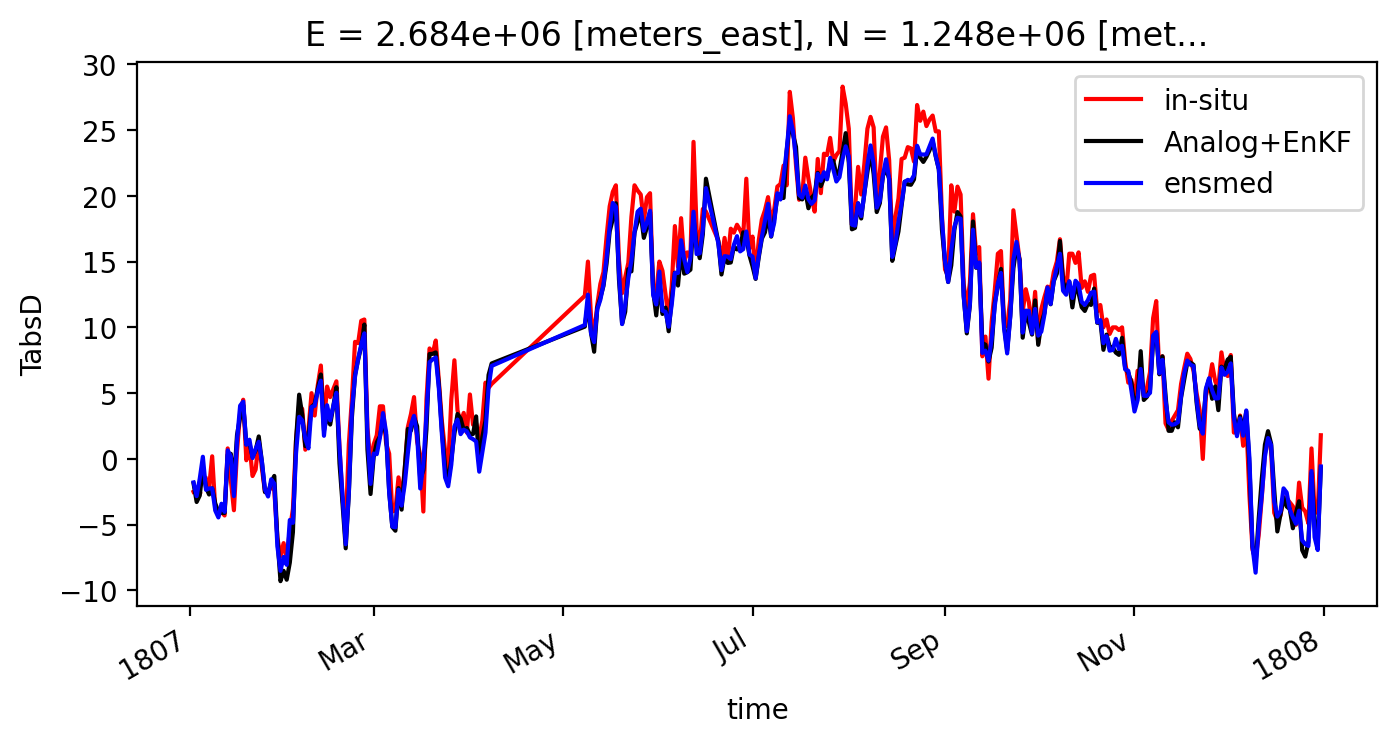

In [46]:
fig = plt.figure(figsize=(8, 4), dpi= 200)

GCOS_Zurich_Feer_1807_intersection.Value.plot(label="in-situ",color="red")
noemi.sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).plot(label="Analog+EnKF",color="black")
ensmed.sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).plot(label="ensmed",color="blue")
plt.legend()

#### Correlation Station vs Noemi

In [47]:
GCOS_Zurich_Feer_1807_intersection.Value.corr(noemi.sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).to_pandas())

0.9890411071403467

#### Correlation Station vs Martin

In [48]:

enssize=ensemble.shape[0]
liste_corr=[]
for i in range(enssize):
    print(GCOS_Zurich_Feer_1807_intersection.Value.corr(ensemble.isel(member=i).sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).to_pandas()))
    liste_corr.append(GCOS_Zurich_Feer_1807_intersection.Value.corr(ensemble.isel(member=i).sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).to_pandas()))

0.9902550358587429
0.9901054574571683
0.9902770420499344
0.9897715299344487
0.9903459379922372
0.9903739773399293
0.9904126584929297
0.9899128535722402
0.9908675718864848
0.9901886040072972
0.9907500644244432
0.9912005446719602
0.9909319751144611
0.9905293534757932
0.991387993206729
0.991083002253108
0.9908811093582367
0.9911535608966711
0.9913381716940444
0.9909284323167951
0.990960176401252
0.990637665405132
0.9912176614232681
0.990497256475716
0.9909282157768335
0.9906152565767555
0.9908582687753602
0.9911298011012495
0.9910423666272972
0.9907979056633686
0.9909770624548104
0.9905548439944727
0.990706802102185
0.990640593171541
0.9906316787748957
0.9910707790829331
0.9913346330262459
0.9909894420826753
0.9909955384522063
0.9907480436577166


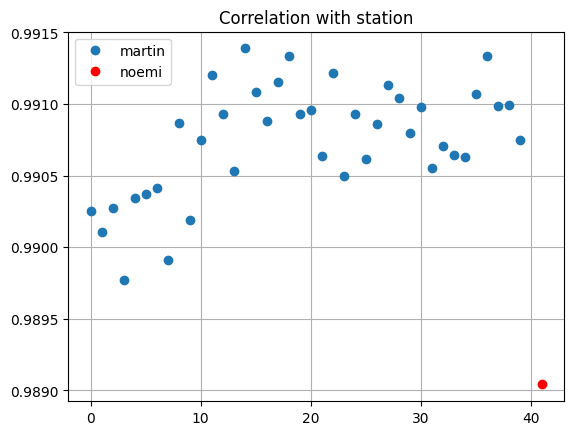

In [49]:
plt.plot(liste_corr,"o",label="martin")
plt.plot(41,GCOS_Zurich_Feer_1807_intersection.Value.corr(noemi.sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).to_pandas()),"o",color="red",label="noemi")
plt.title("Correlation with station")
plt.grid()
plt.legend()

#### RMSE Station vs Noemi

In [50]:
rmse = np.sqrt(((GCOS_Zurich_Feer_1807_intersection.Value - noemi.sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).to_pandas()) ** 2).mean())
print(rmse)

1.767435292195269


#### RMSE Station vs Martin

In [51]:

liste_rmse=[]
for i in range(enssize):
    rmse = np.sqrt(((GCOS_Zurich_Feer_1807_intersection.Value - ensemble.isel(member=i).sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).to_pandas()) ** 2).mean())
    liste_rmse.append(rmse)
    print(rmse)

1.6654655819644089
1.5504435725622094
1.7682844085664184
1.5501546482664017
1.6325766108368882
1.61636578517894
1.596138232937257
1.8163309488653876
1.7672280685229789
1.8080547172464934
1.664842407034387
1.6492526784201962
1.5459468843761774
1.6012291340024212
1.5621040148134888
1.6712449556912974
1.6250029189287403
1.7298998270994523
1.6493485193995525
1.6051543432963629
1.6520827016673638
1.7788477946260177
1.546650440412395
1.7349249879144073
1.7739538911147374
1.62241702589341
1.5286746064902368
1.5590795373672584
1.6827961637958018
1.5905392664992144
1.6292169679613293
1.6853730614838478
1.6091179850986763
1.6669362067724982
1.6079714352211096
1.6461926883055817
1.6514922083938173
1.6896541123653621
1.7223436001074857
1.525332239201851


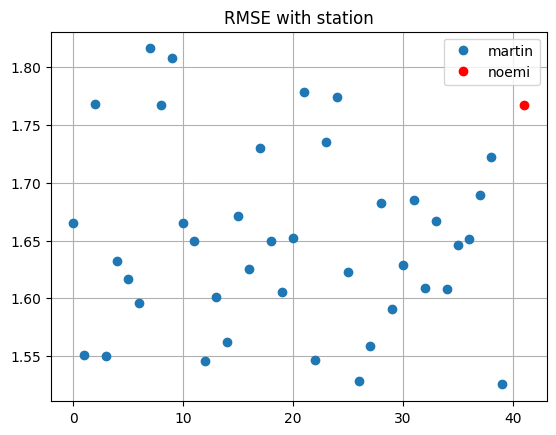

In [52]:
plt.plot(liste_rmse,"o",label="martin")
plt.plot(41,np.sqrt(((GCOS_Zurich_Feer_1807_intersection.Value - noemi.sel(E=2683484.331,N=1247341.058,method="nearest").sel(time=common_times).to_pandas()) ** 2).mean()),"o",color="red",label="noemi")
plt.title("RMSE with station")
plt.grid()
plt.legend()